# One ancilla per edge: the rotating rounds

`experiments/one_ancilla.py`, step by step. One ancilla sits halfway along every edge, instead of the
syndrome-and-reference pair `src/floquet.py` puts there. A step rotates the data one place around the
hexes of one colour, measures, and rotates them back, so every gate is between neighbouring dots.
`make experiments` saves the same drawings as PNGs.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

from IPython.display import SVG, display

# works whether the kernel starts in the repo root or in experiments/
sys.path.insert(0, str(next(p for p in (Path.cwd(), Path.cwd() / "experiments", Path.cwd().parent)
                            if (p / "one_ancilla.py").exists())))

from one_ancilla import (check, layout_figure, qubits, rotated, round_circuit, round_svg,
                         syndrome_checks)

In [2]:
# The Makefile's DRAW_DISTANCE. 1 is 12 data qubits and 18 ancillas; 2 is 48 and 72.
DISTANCE = 1
NUMBERS = True  # label every qubit: Di data qubit i, Ak ancilla of edge k, Sk a syndrome
names = ["blue", "red", "green"]  # colour 0, 1, 2, as plots.py draws them

## The layout

Data qubits on the hexagon corners (filled), one ancilla halfway along each edge (hollow), on a torus of
2·d columns by 3·d rows. An edge's colour is the colour of the two hexagons it links, so a hexagon's own
six sides are the two other colours. The brick-wall view is the coordinates the circuits use; the hexagon
view only moves where each qubit is drawn.

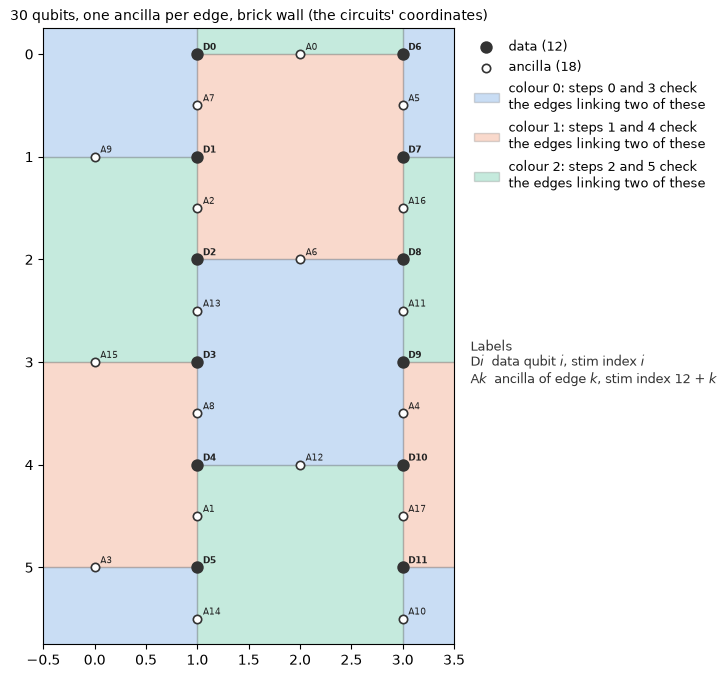

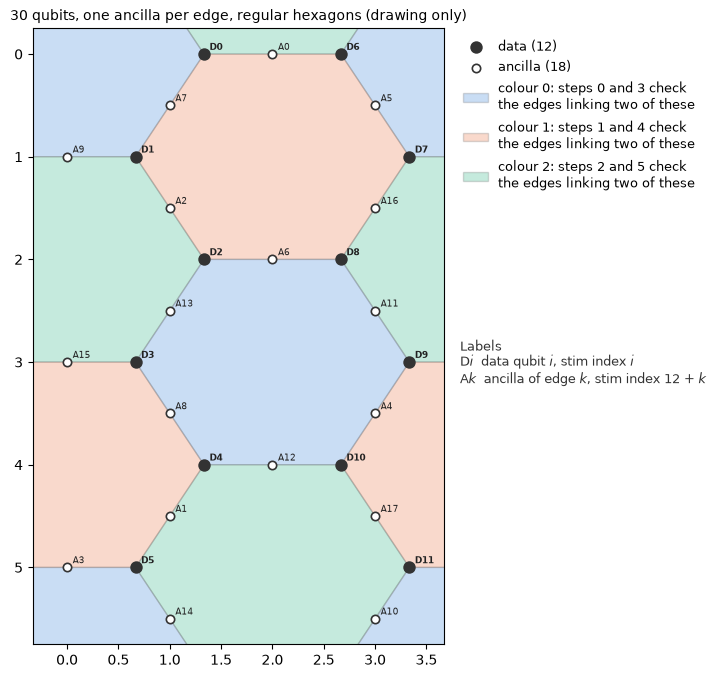

In [3]:
for hex_view in (False, True):
    layout_figure(DISTANCE, hex_view, NUMBERS)

## Which hexes rotate, and what that measures

Rotating a hexagon's data one step counterclockwise leaves an ancilla on each corner with two data
qubits beside it, one from each neighbouring corner. Taking every other corner, those pairs are exactly
one colour class of edges, each data qubit in one pair. Colour c edges come from rotating the colour
c + 1 hexes, which is `rotated(r)`, so the steps run the `bX rZ gX bZ rX gZ` schedule of `floquet.py`.

In [4]:
labels = {q: f"D{i}" for i, q in enumerate(qubits(DISTANCE))}
for r in range(6):
    checks = syndrome_checks(DISTANCE, rotated(r))
    pairs = ", ".join(f"{labels[u]}-{labels[v]}" for _, u, v, _ in checks[:3])
    pauli = "XZ"[r % 2] * 2
    print(f"step {r}: {pauli} on {names[r % 3]:5} edges, rotating {names[rotated(r)]:5} hexes"
          f" - {len(checks)} checks, e.g. {pairs}, ...")

step 0: XX on blue  edges, rotating red   hexes - 6 checks, e.g. D7-D8, D11-D10, D9-D3, ...
step 1: ZZ on red   edges, rotating green hexes - 6 checks, e.g. D11-D6, D9-D8, D7-D1, ...
step 2: XX on green edges, rotating blue  hexes - 6 checks, e.g. D0-D1, D4-D3, D2-D8, ...
step 3: ZZ on blue  edges, rotating red   hexes - 6 checks, e.g. D7-D8, D11-D10, D9-D3, ...
step 4: XX on red   edges, rotating green hexes - 6 checks, e.g. D11-D6, D9-D8, D7-D1, ...
step 5: ZZ on green edges, rotating blue  hexes - 6 checks, e.g. D0-D1, D4-D3, D2-D8, ...


## The six steps

Tick 0 rotates counterclockwise and tick 1 shows where everything landed: data (filled) now sit on
ancilla spots, each syndrome `Sk` on a corner, and the ancilla it reads out against in reference grey.
Then the two data gates, an H on XX steps, the MZZ, and a last tick rotating back clockwise. Edges that
wrap around the torus are drawn as long arcs.

step 0: XX on blue edges


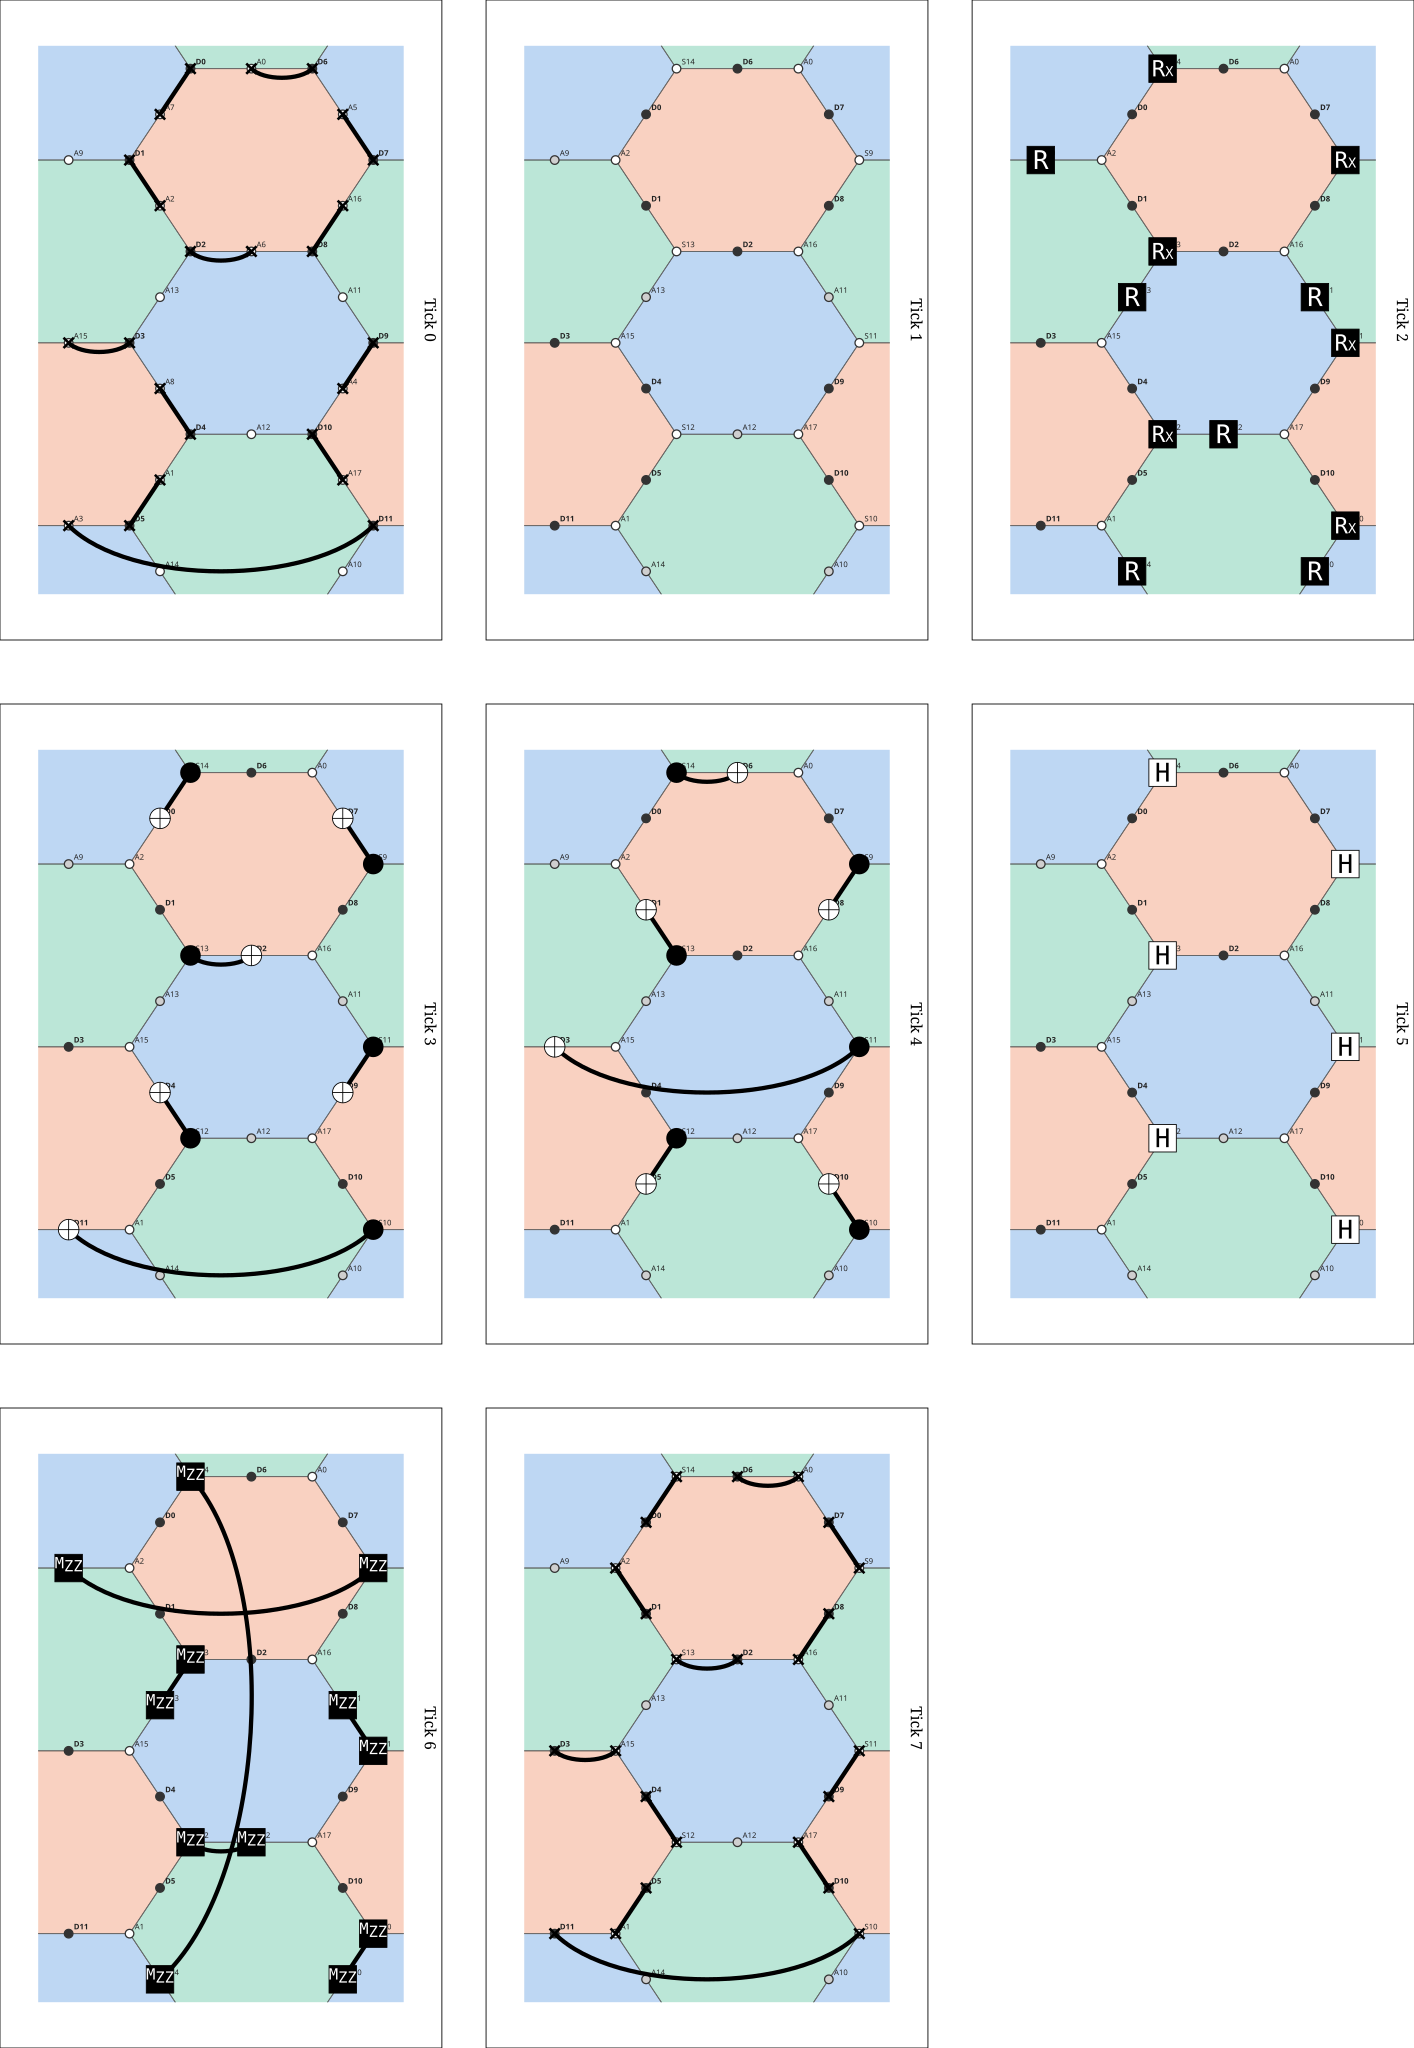

step 1: ZZ on red edges


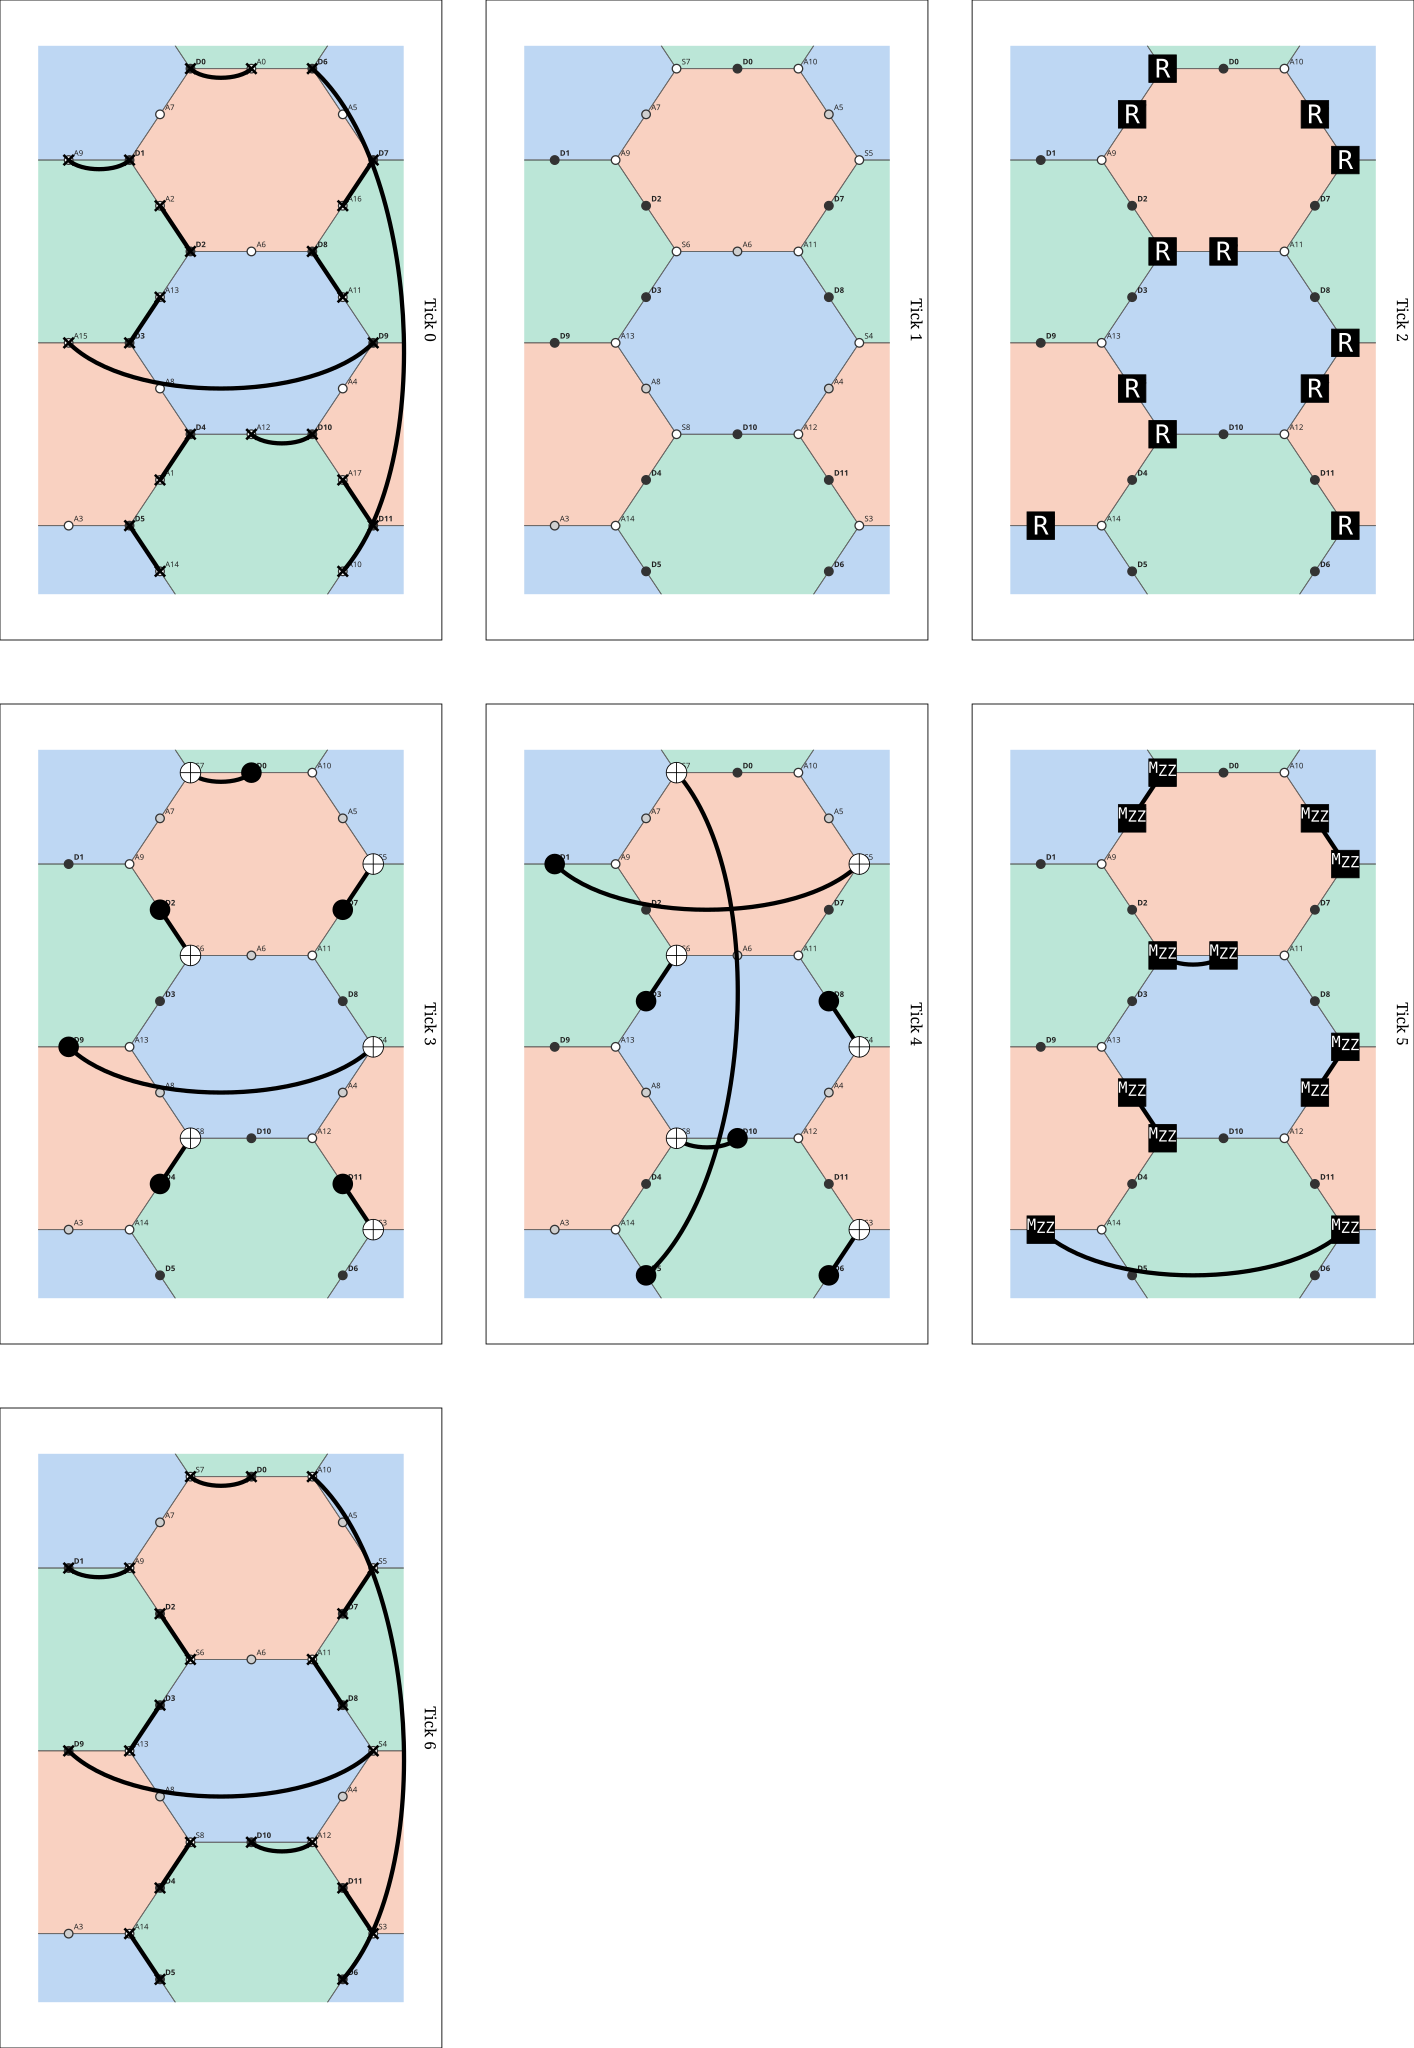

step 2: XX on green edges


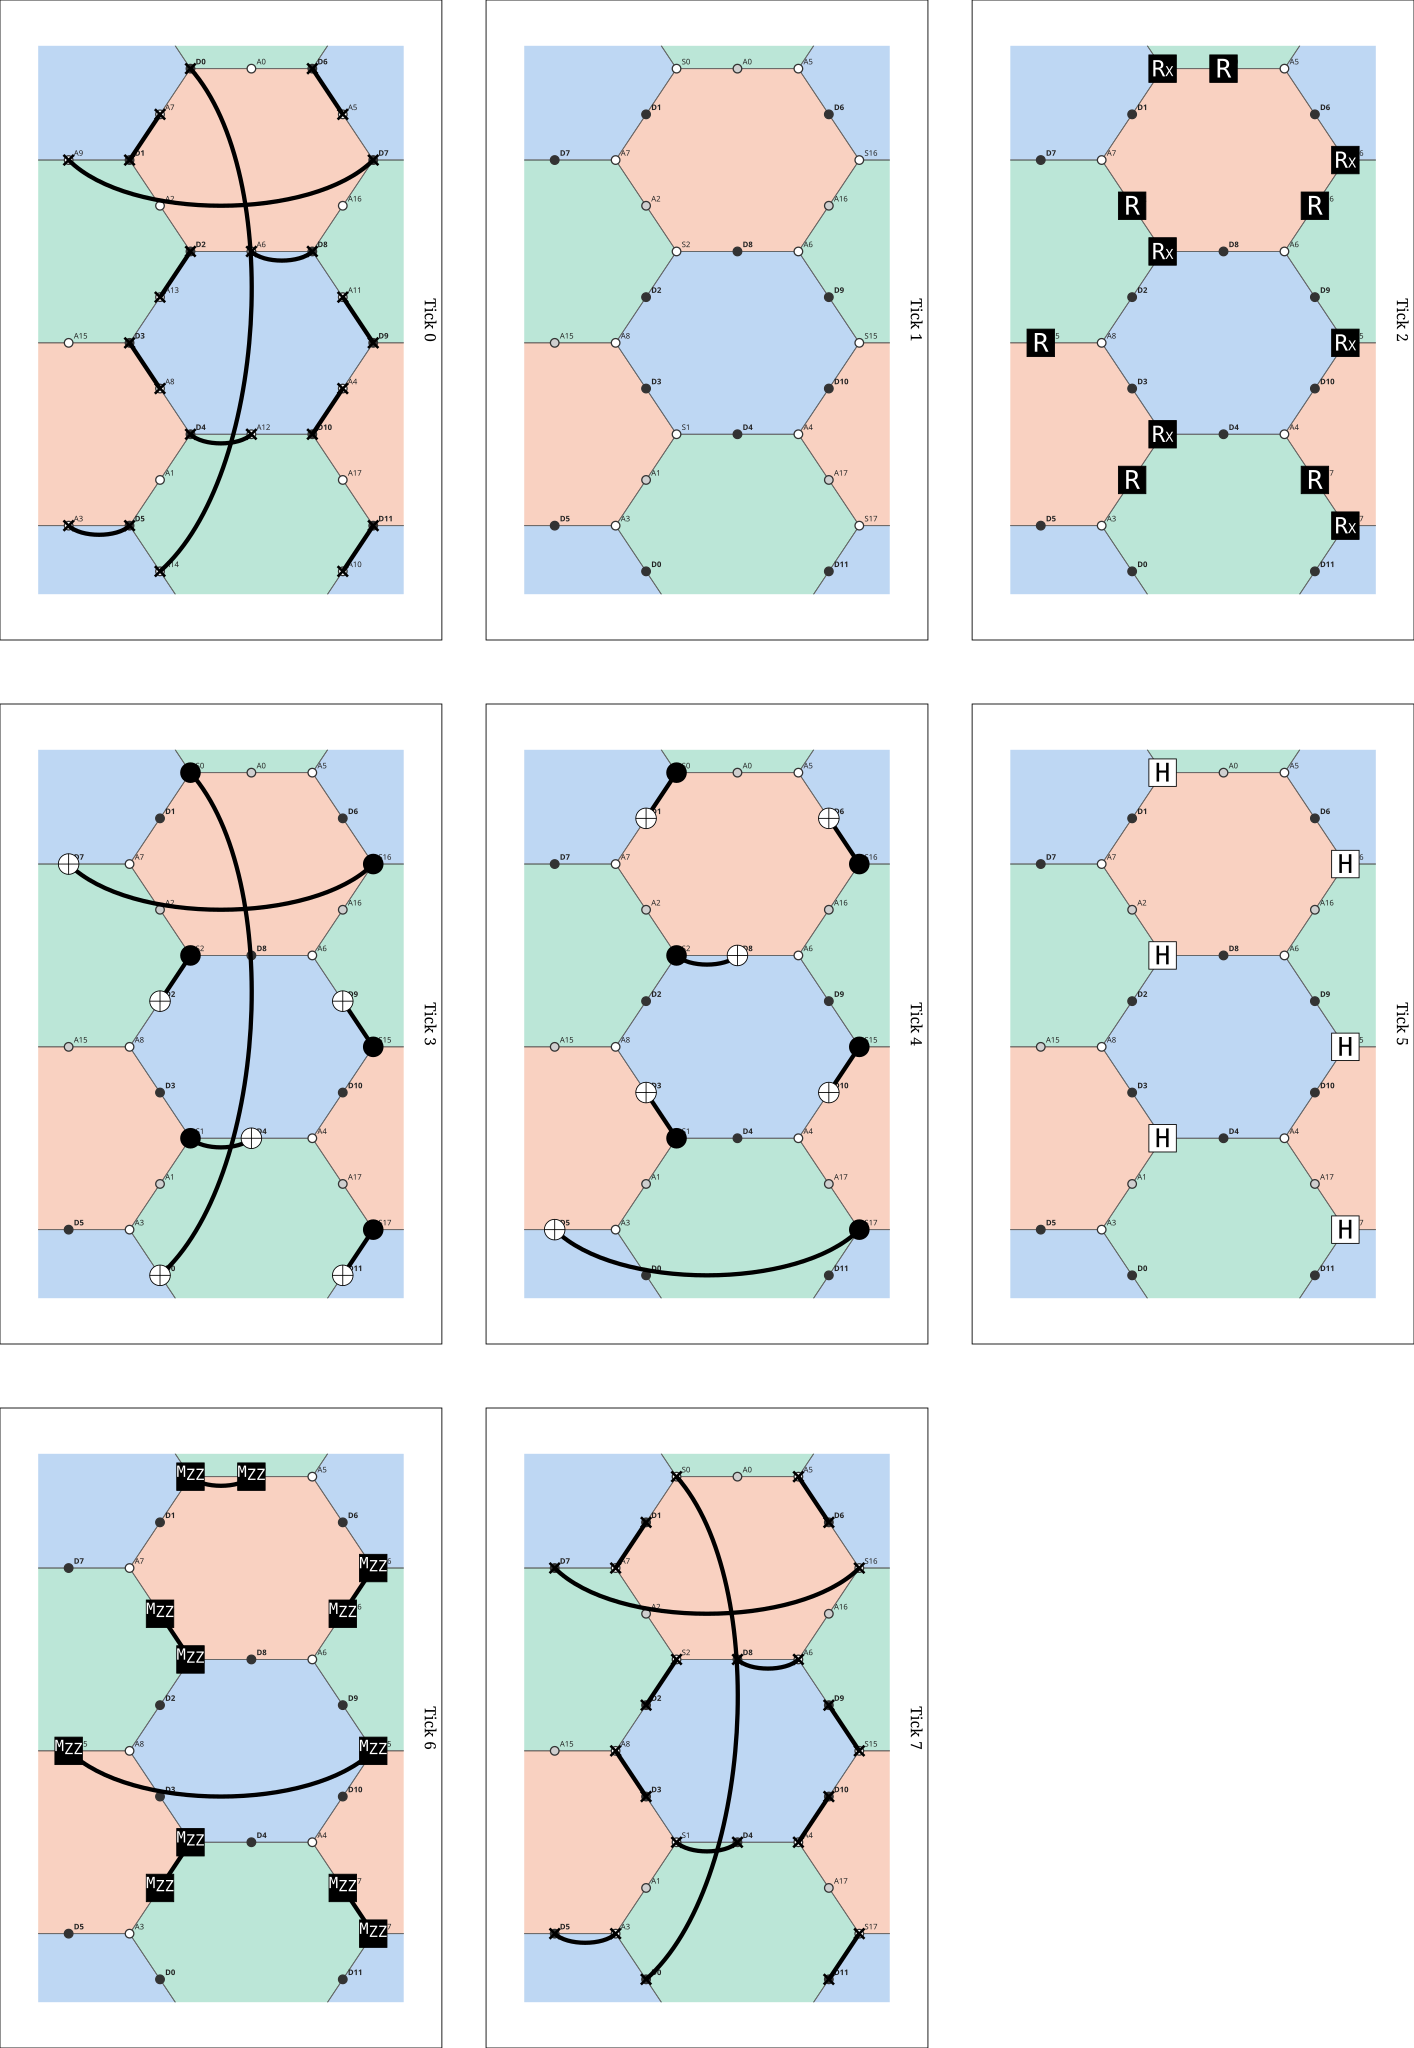

step 3: ZZ on blue edges


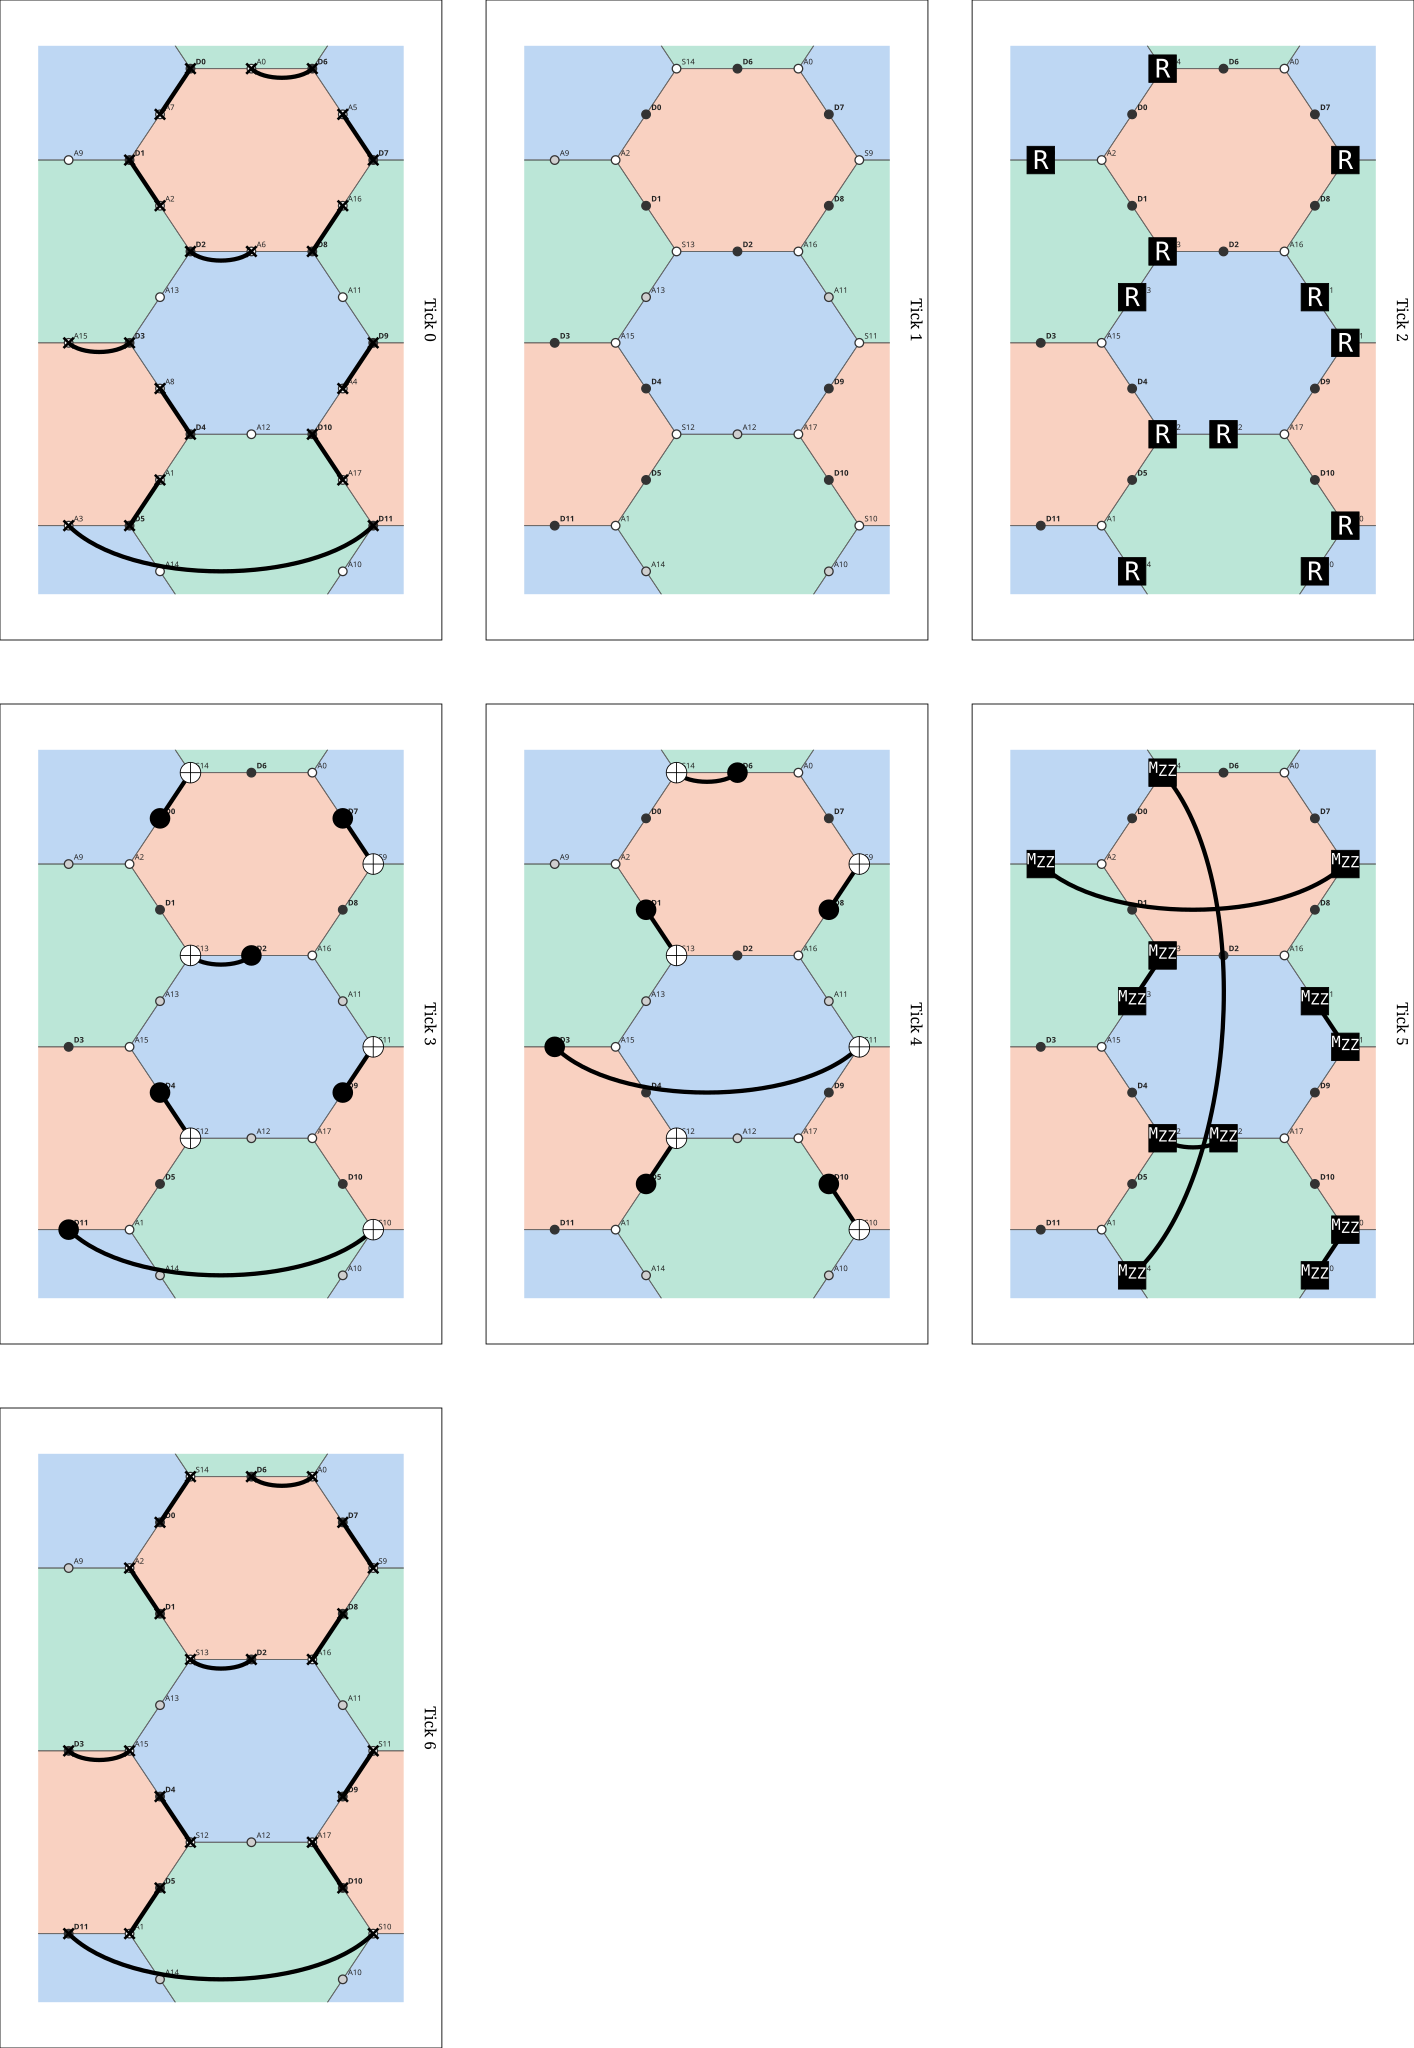

step 4: XX on red edges


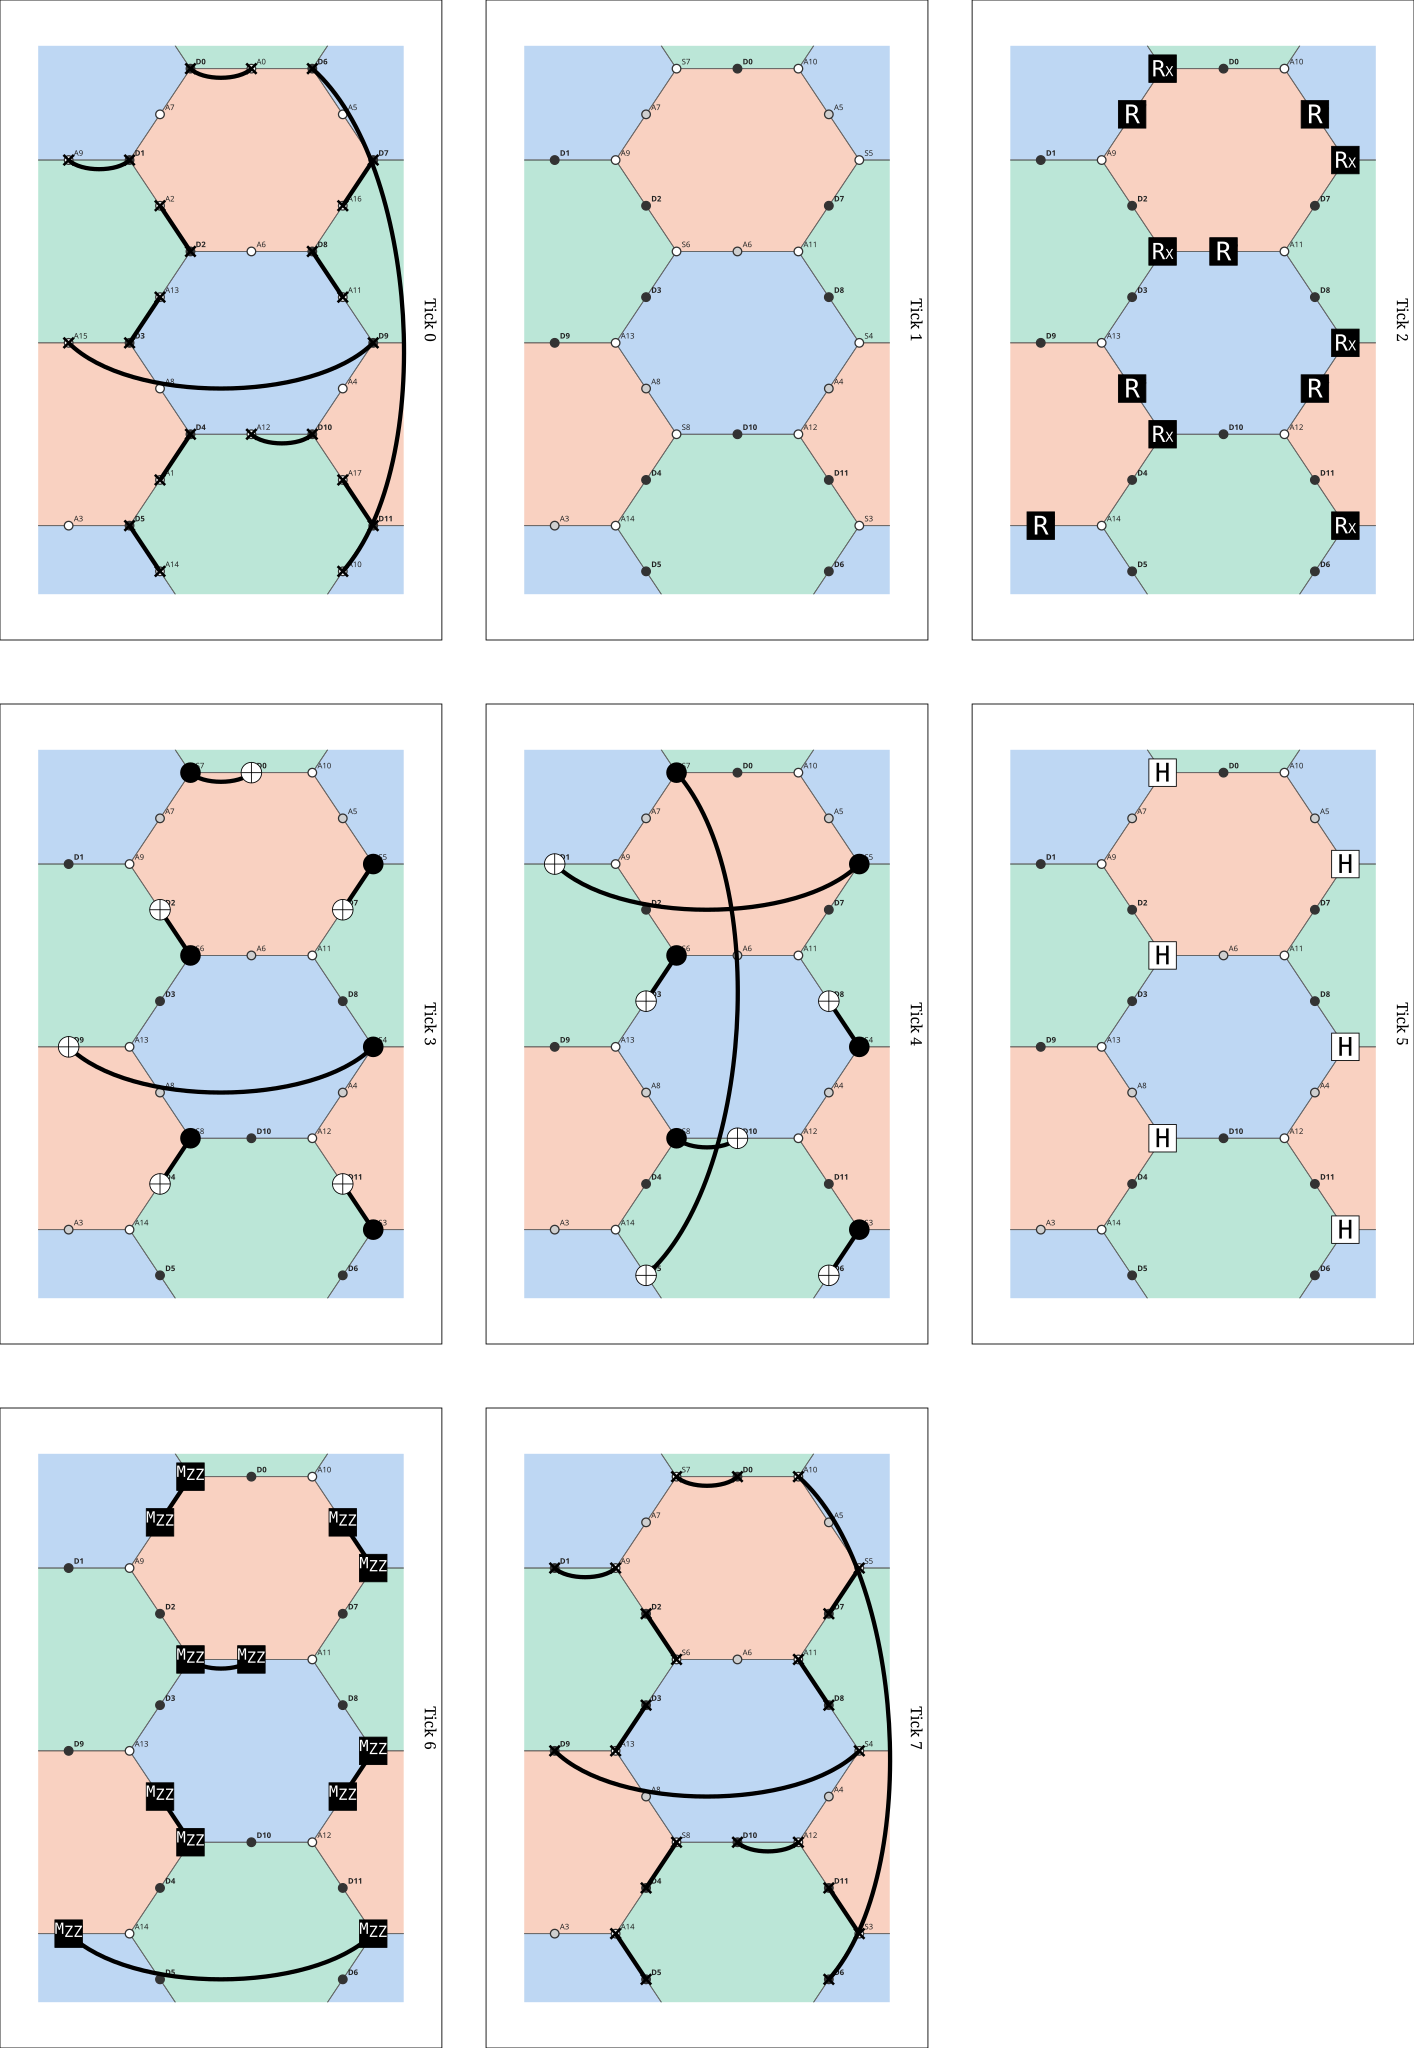

step 5: ZZ on green edges


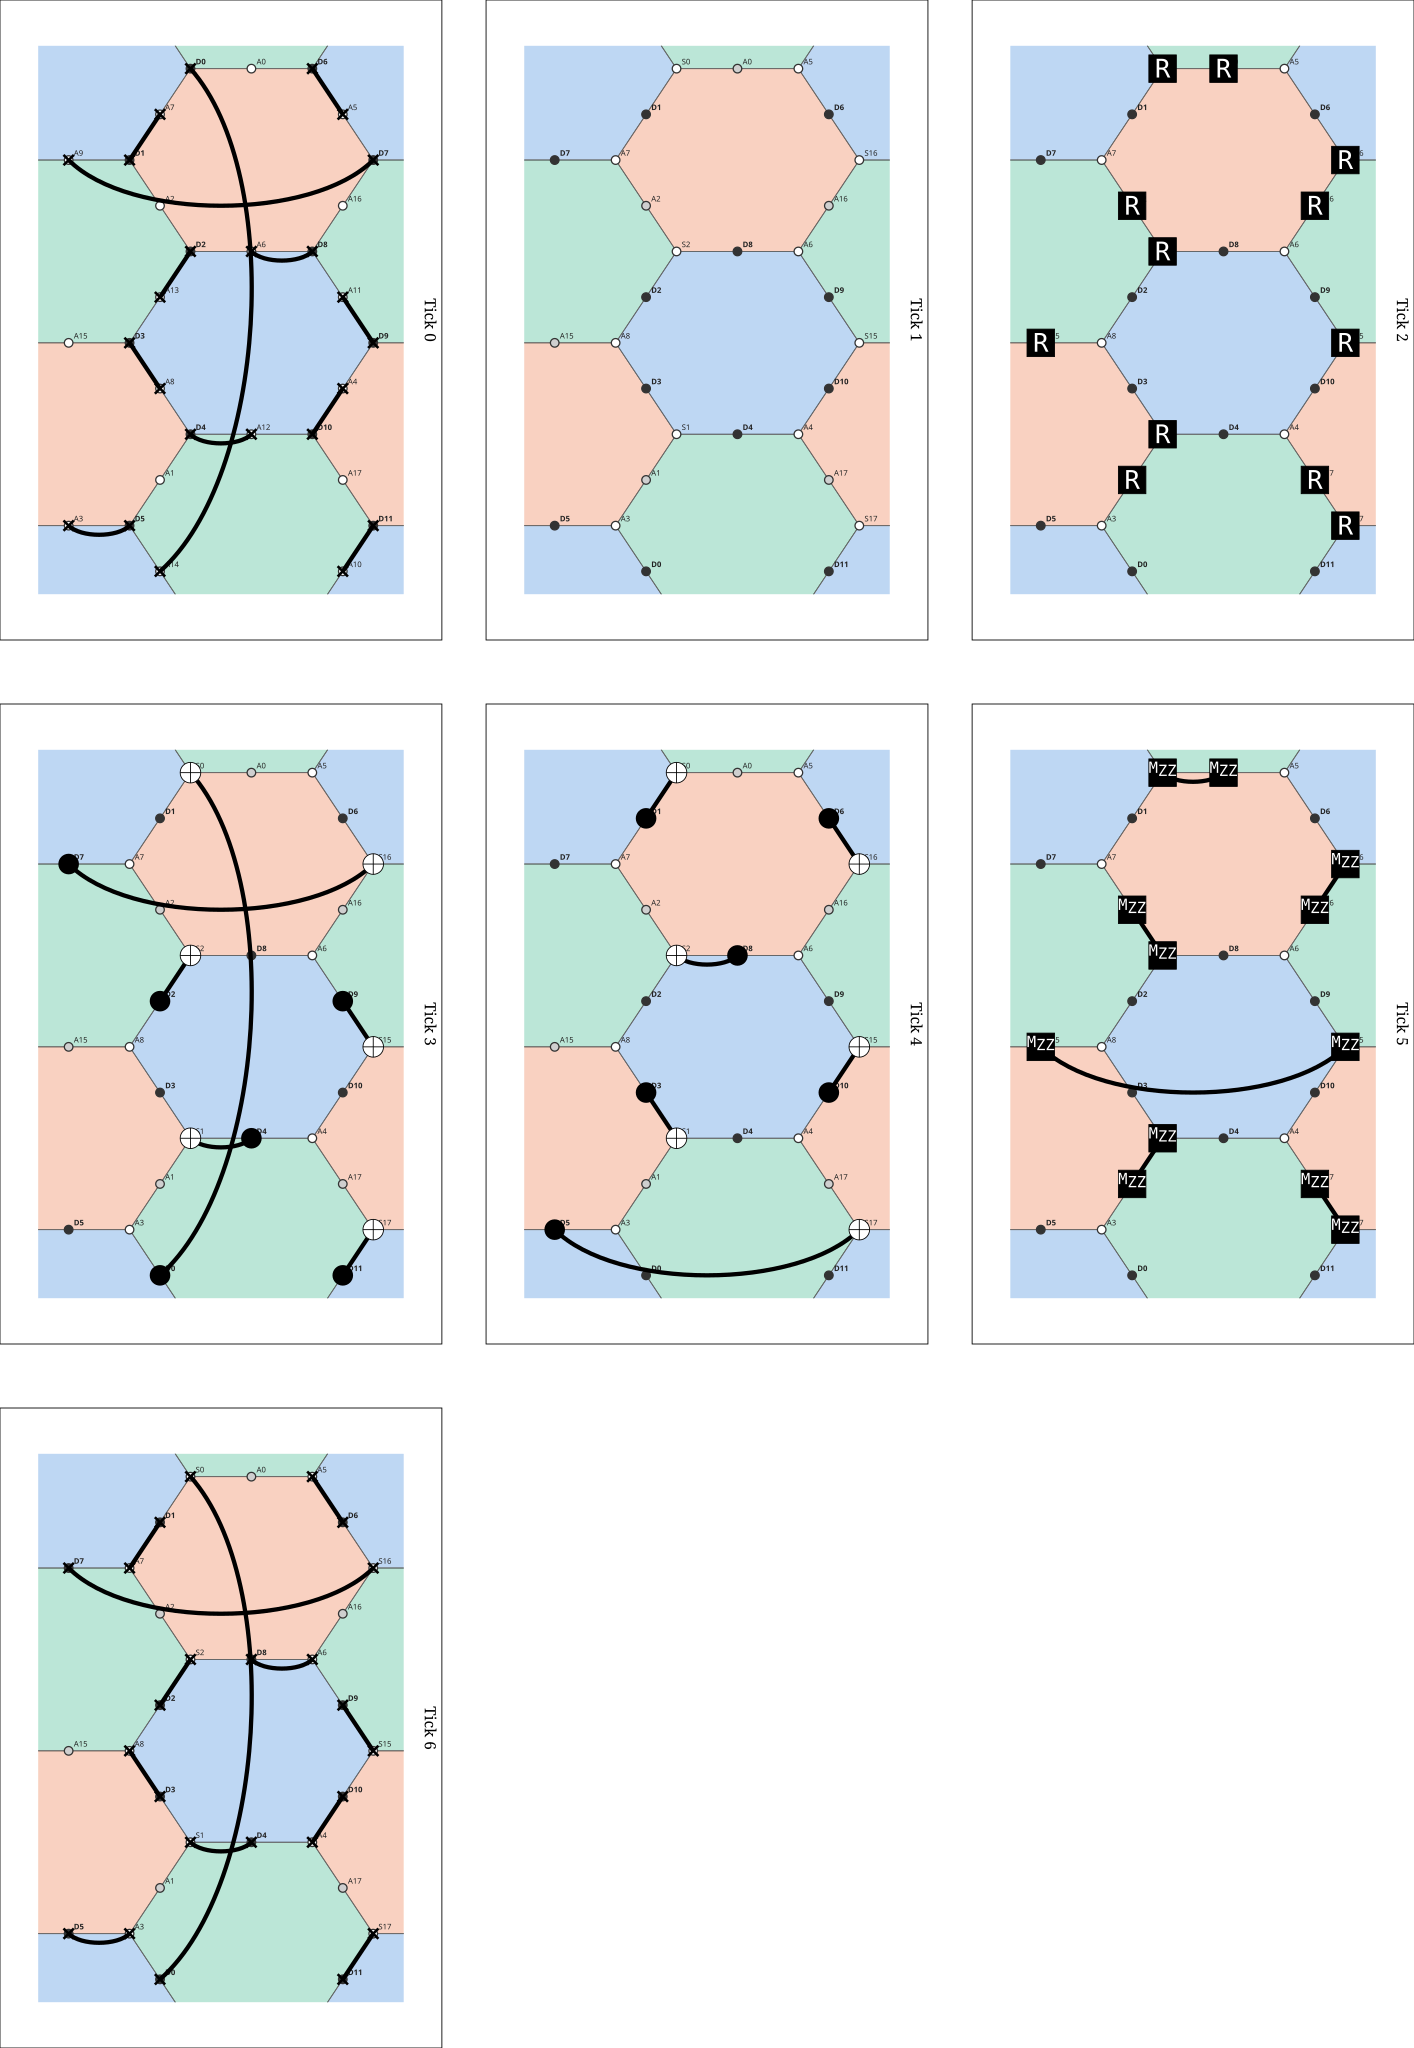

In [5]:
for r in range(6):
    print(f"step {r}: {'XZ'[r % 2] * 2} on {names[r % 3]} edges")
    display(SVG(round_svg(DISTANCE, r, hex_view=True, numbers=NUMBERS)))

The same steps in brick-wall coordinates, which is what the circuits carry as QUBIT_COORDS.

step 0: XX on blue edges


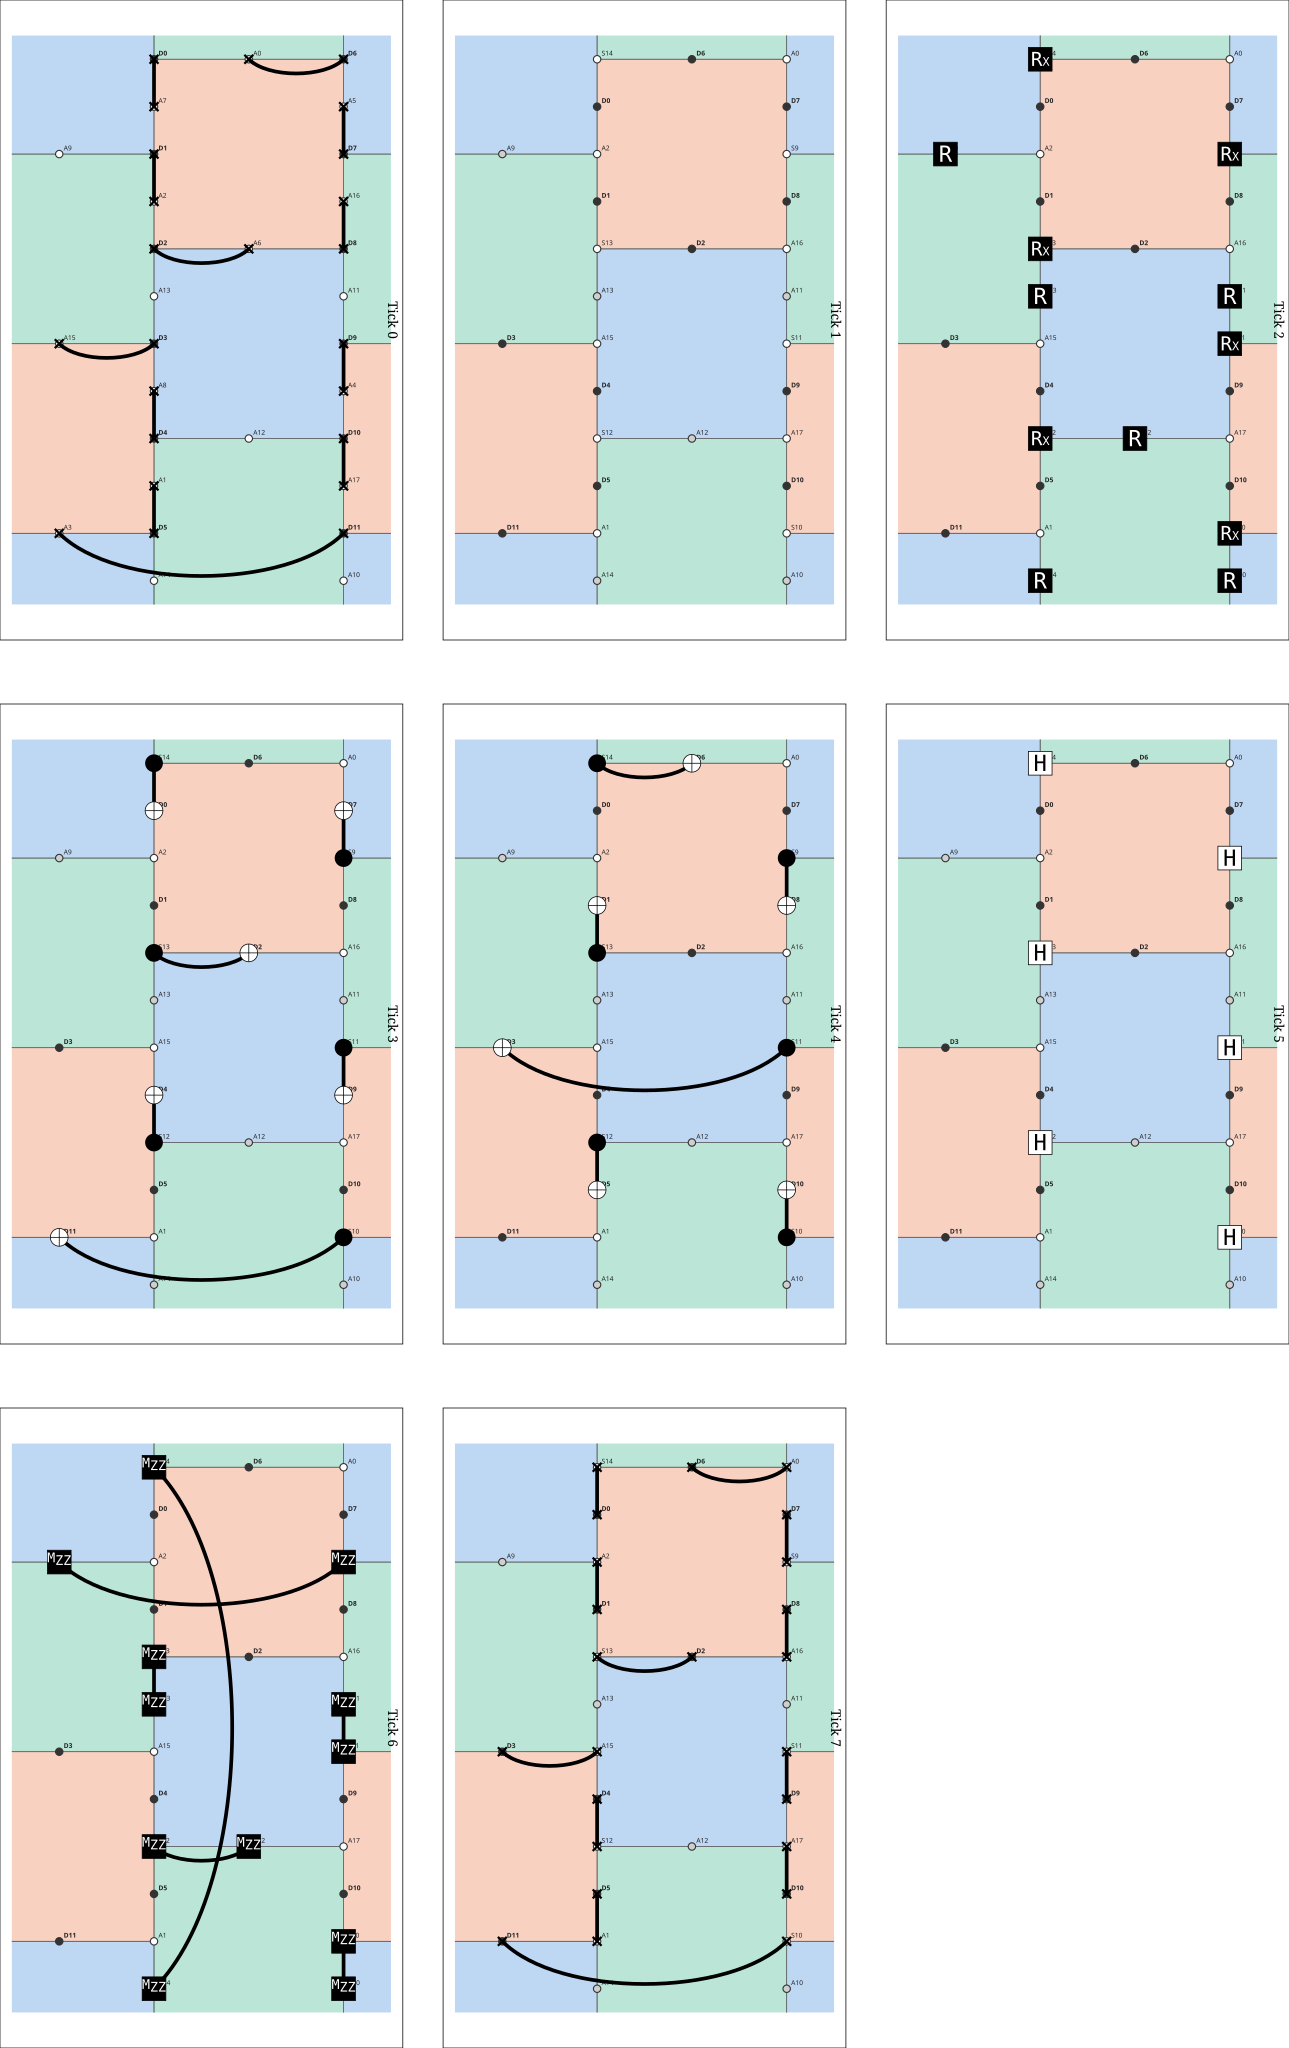

step 1: ZZ on red edges


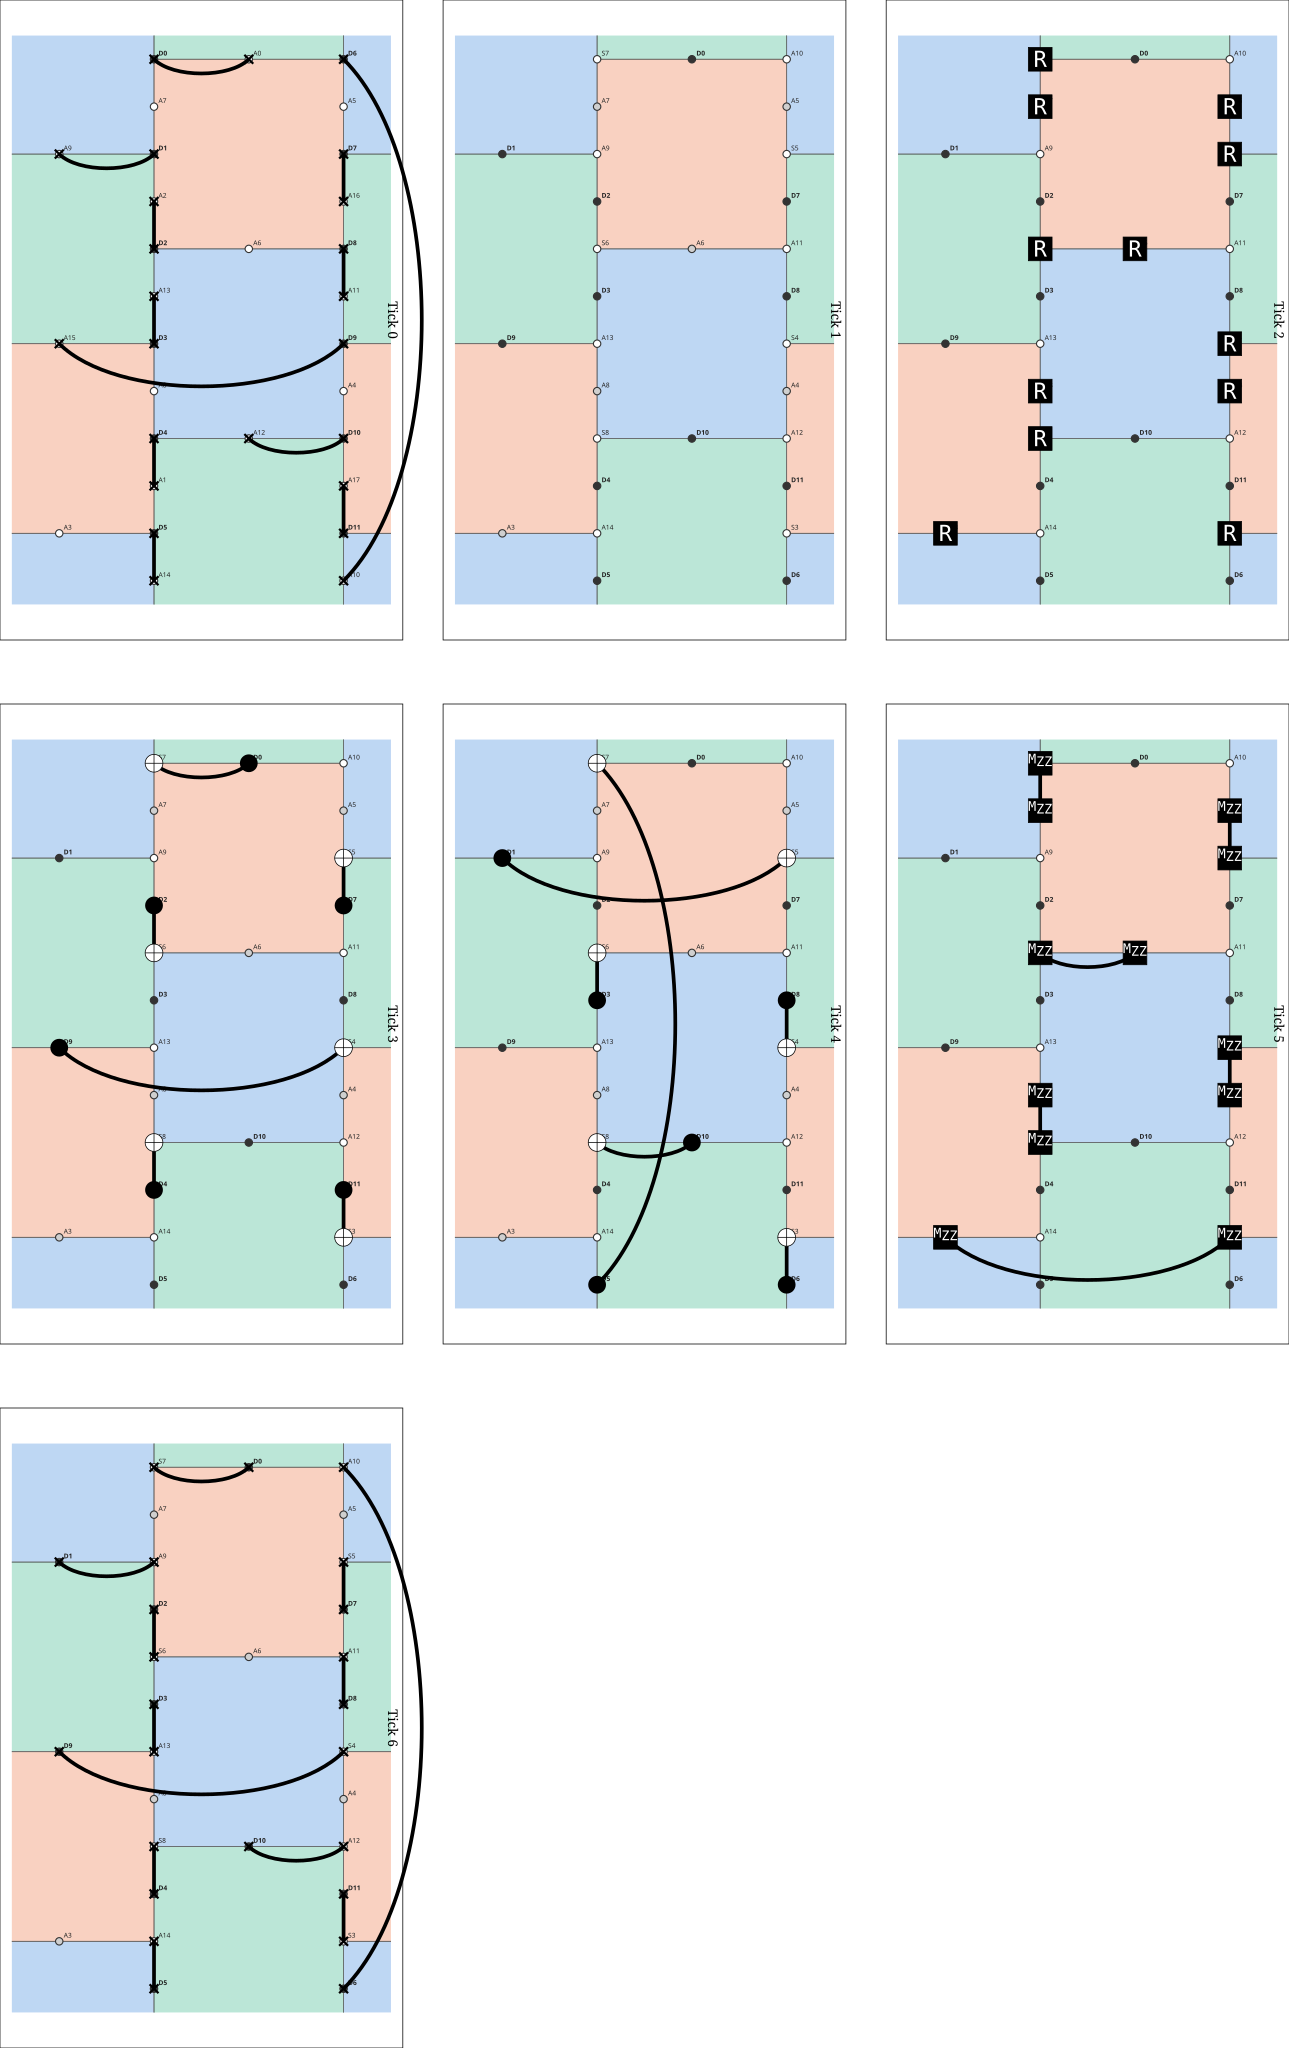

step 2: XX on green edges


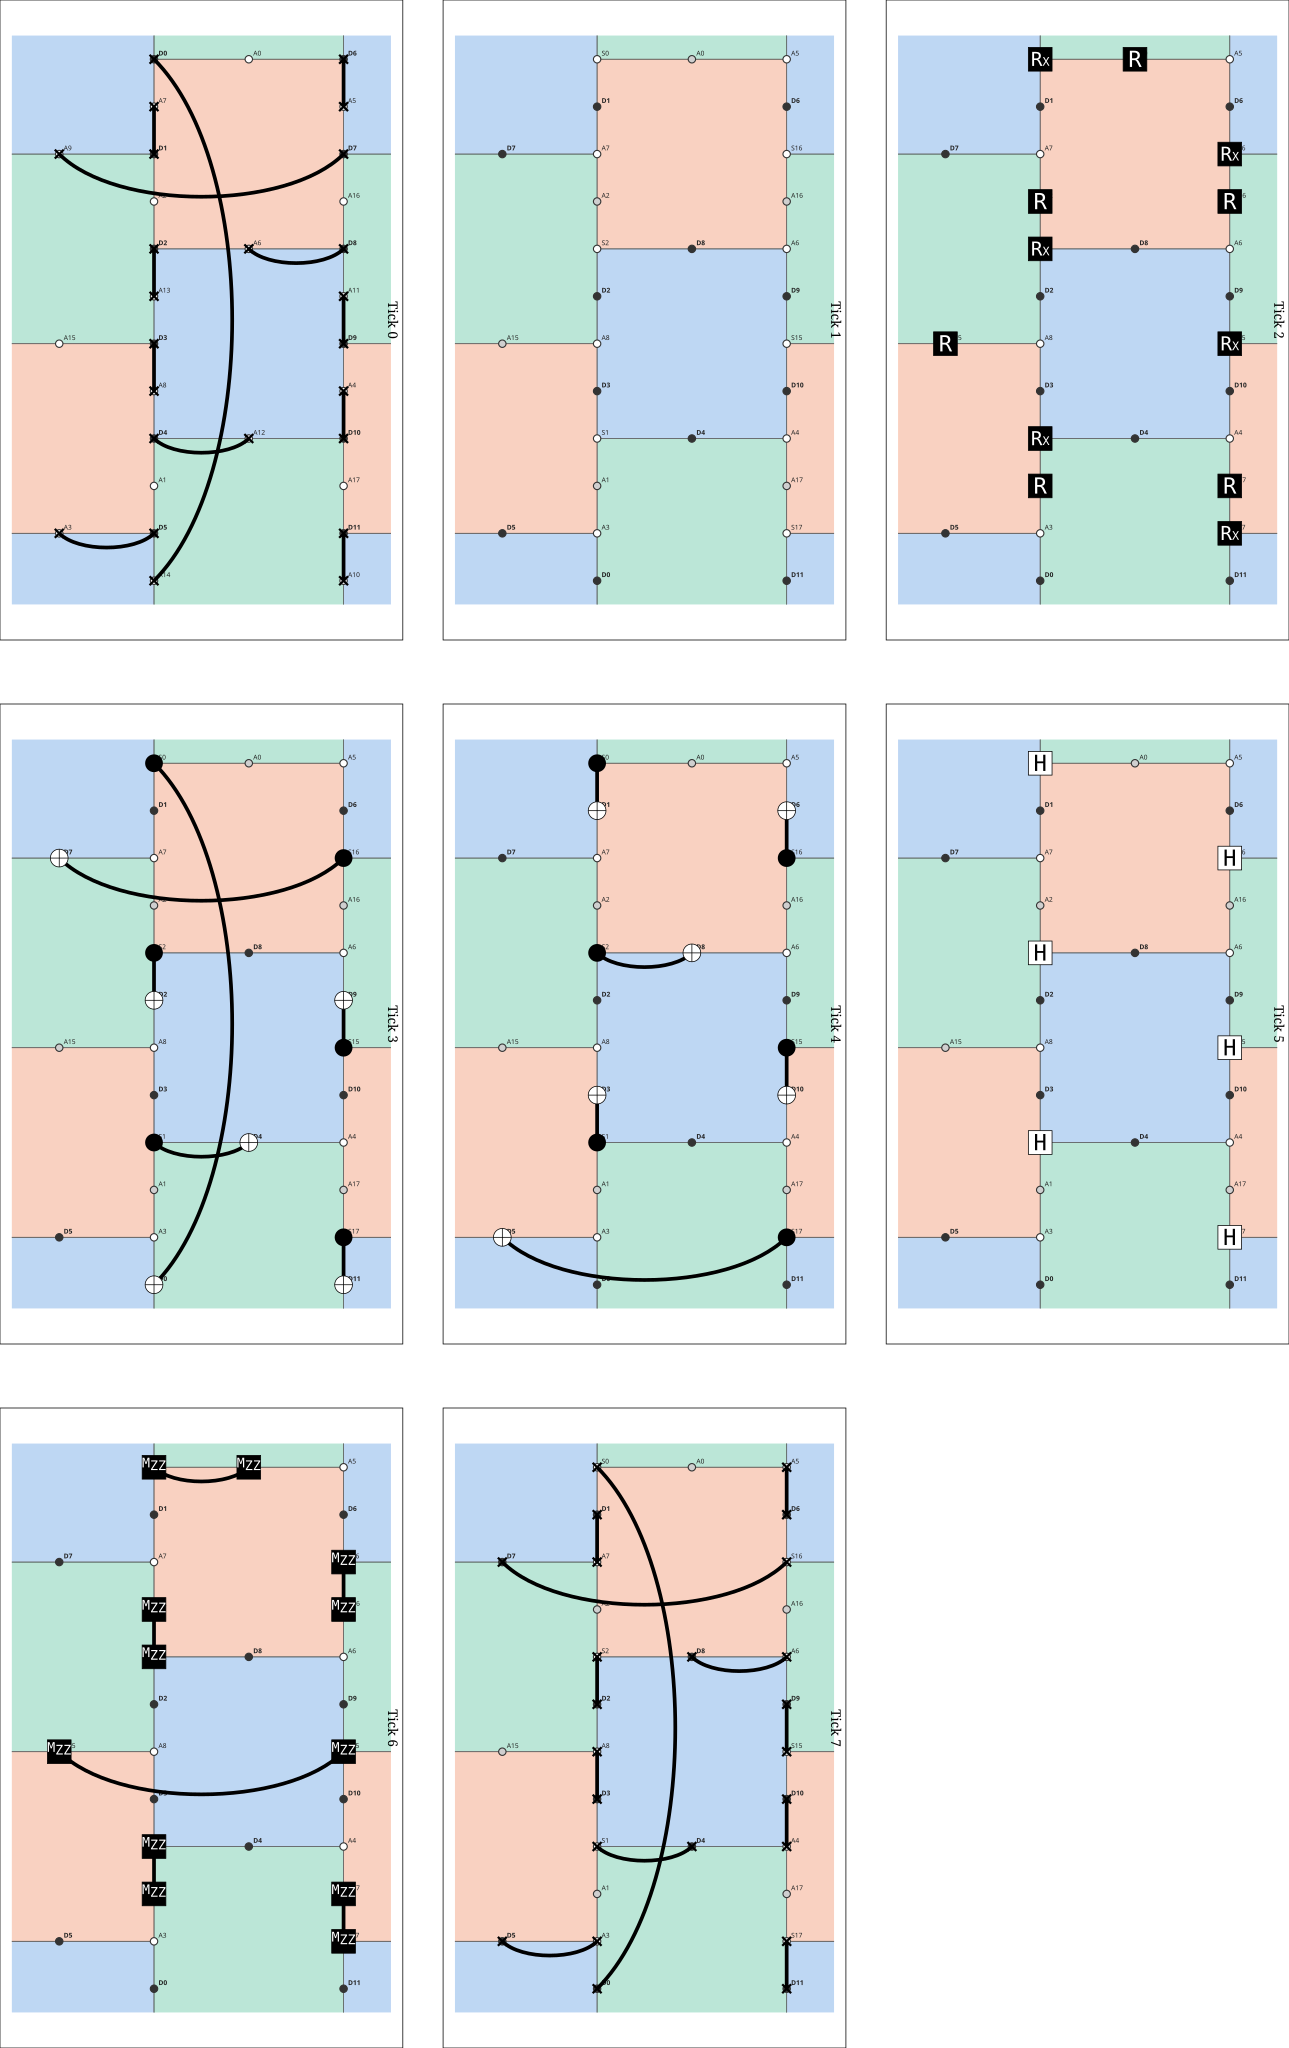

step 3: ZZ on blue edges


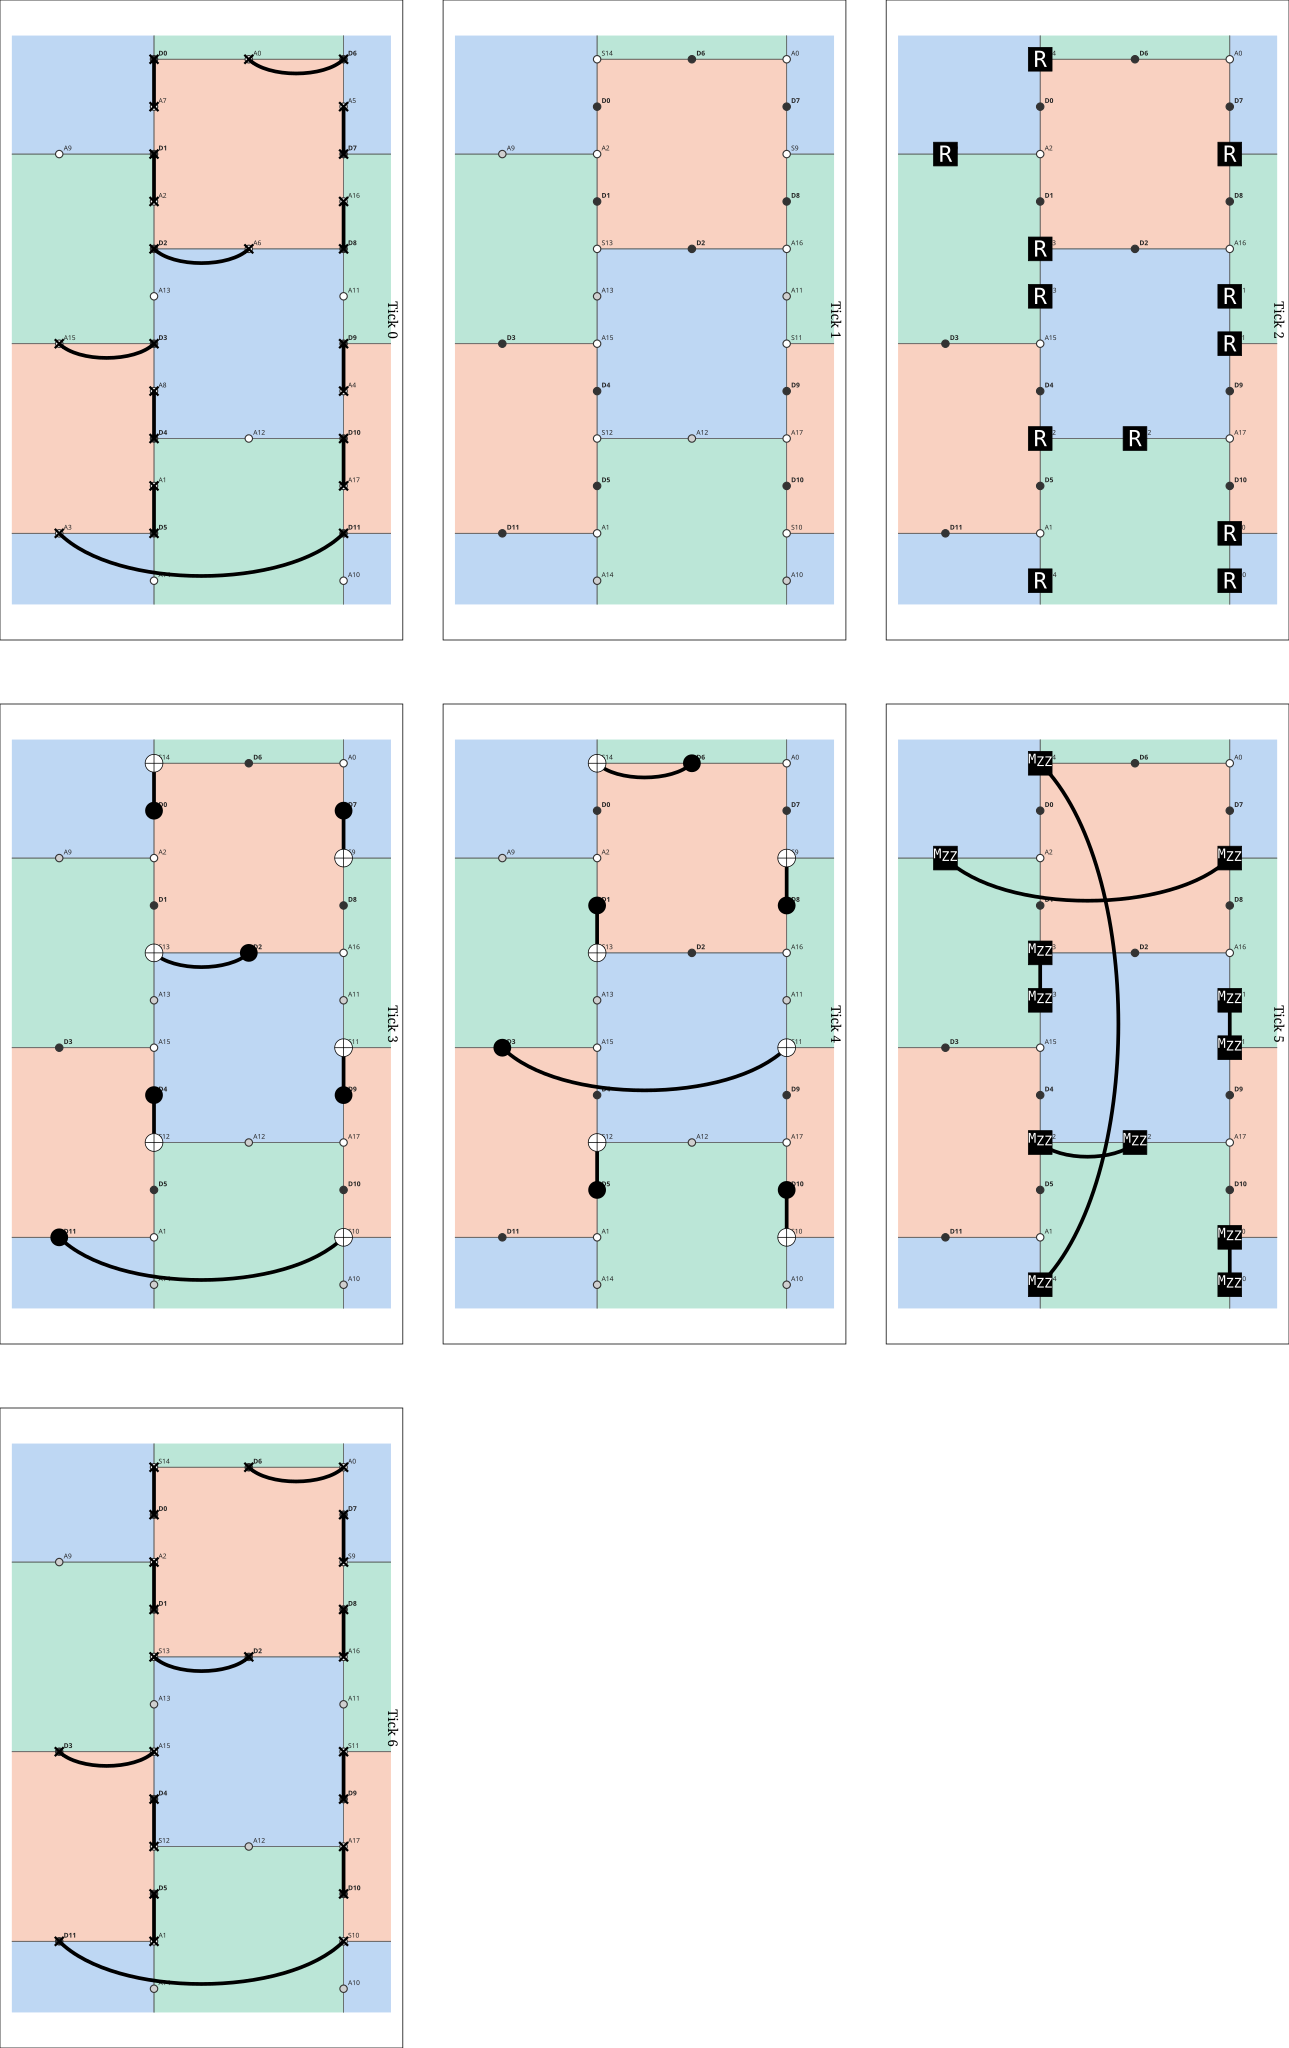

step 4: XX on red edges


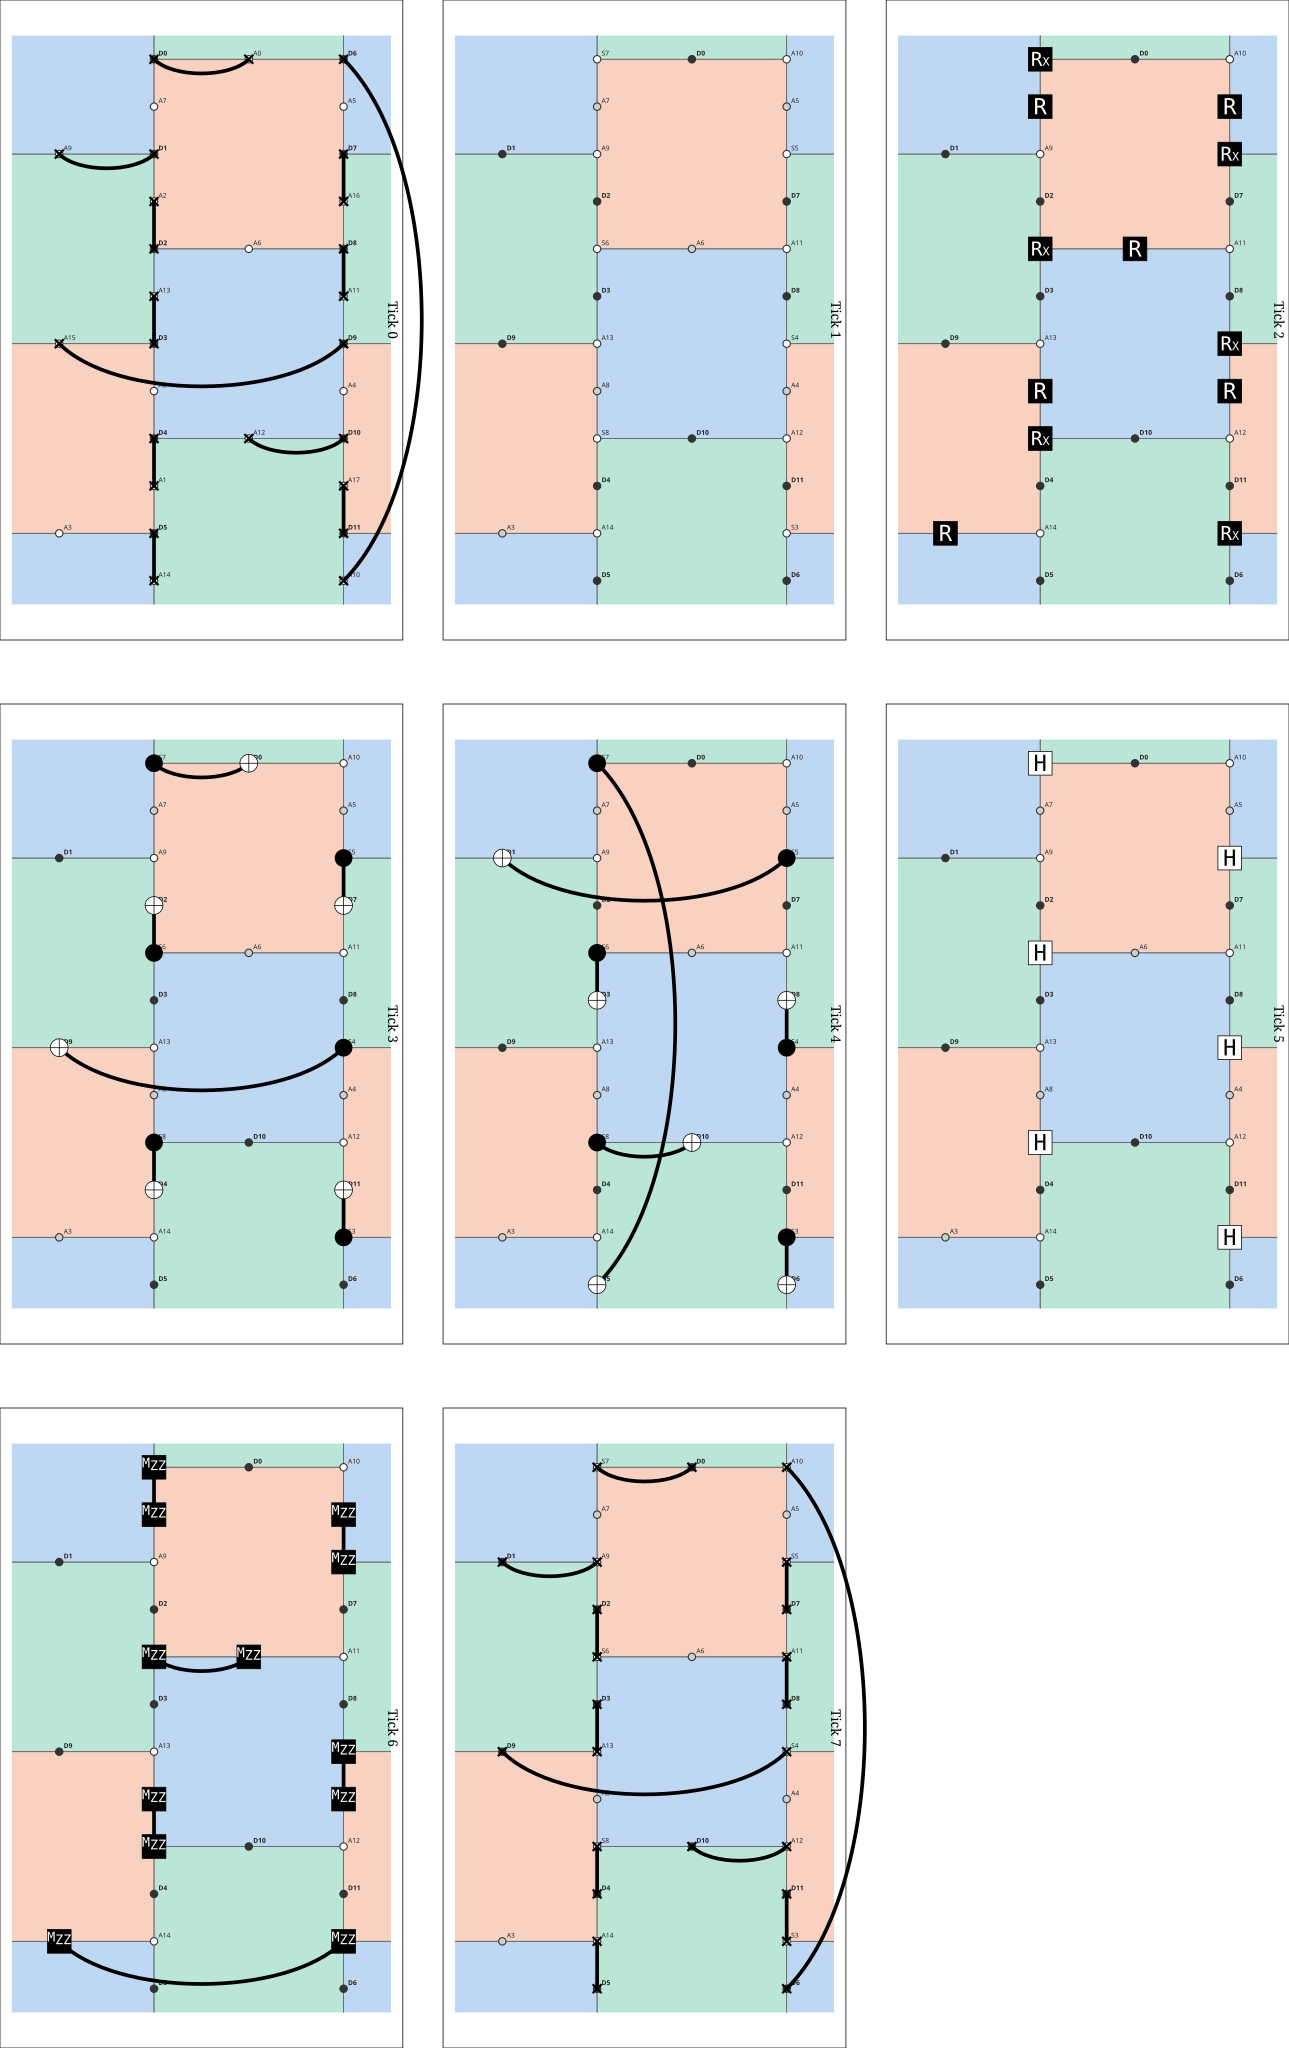

step 5: ZZ on green edges


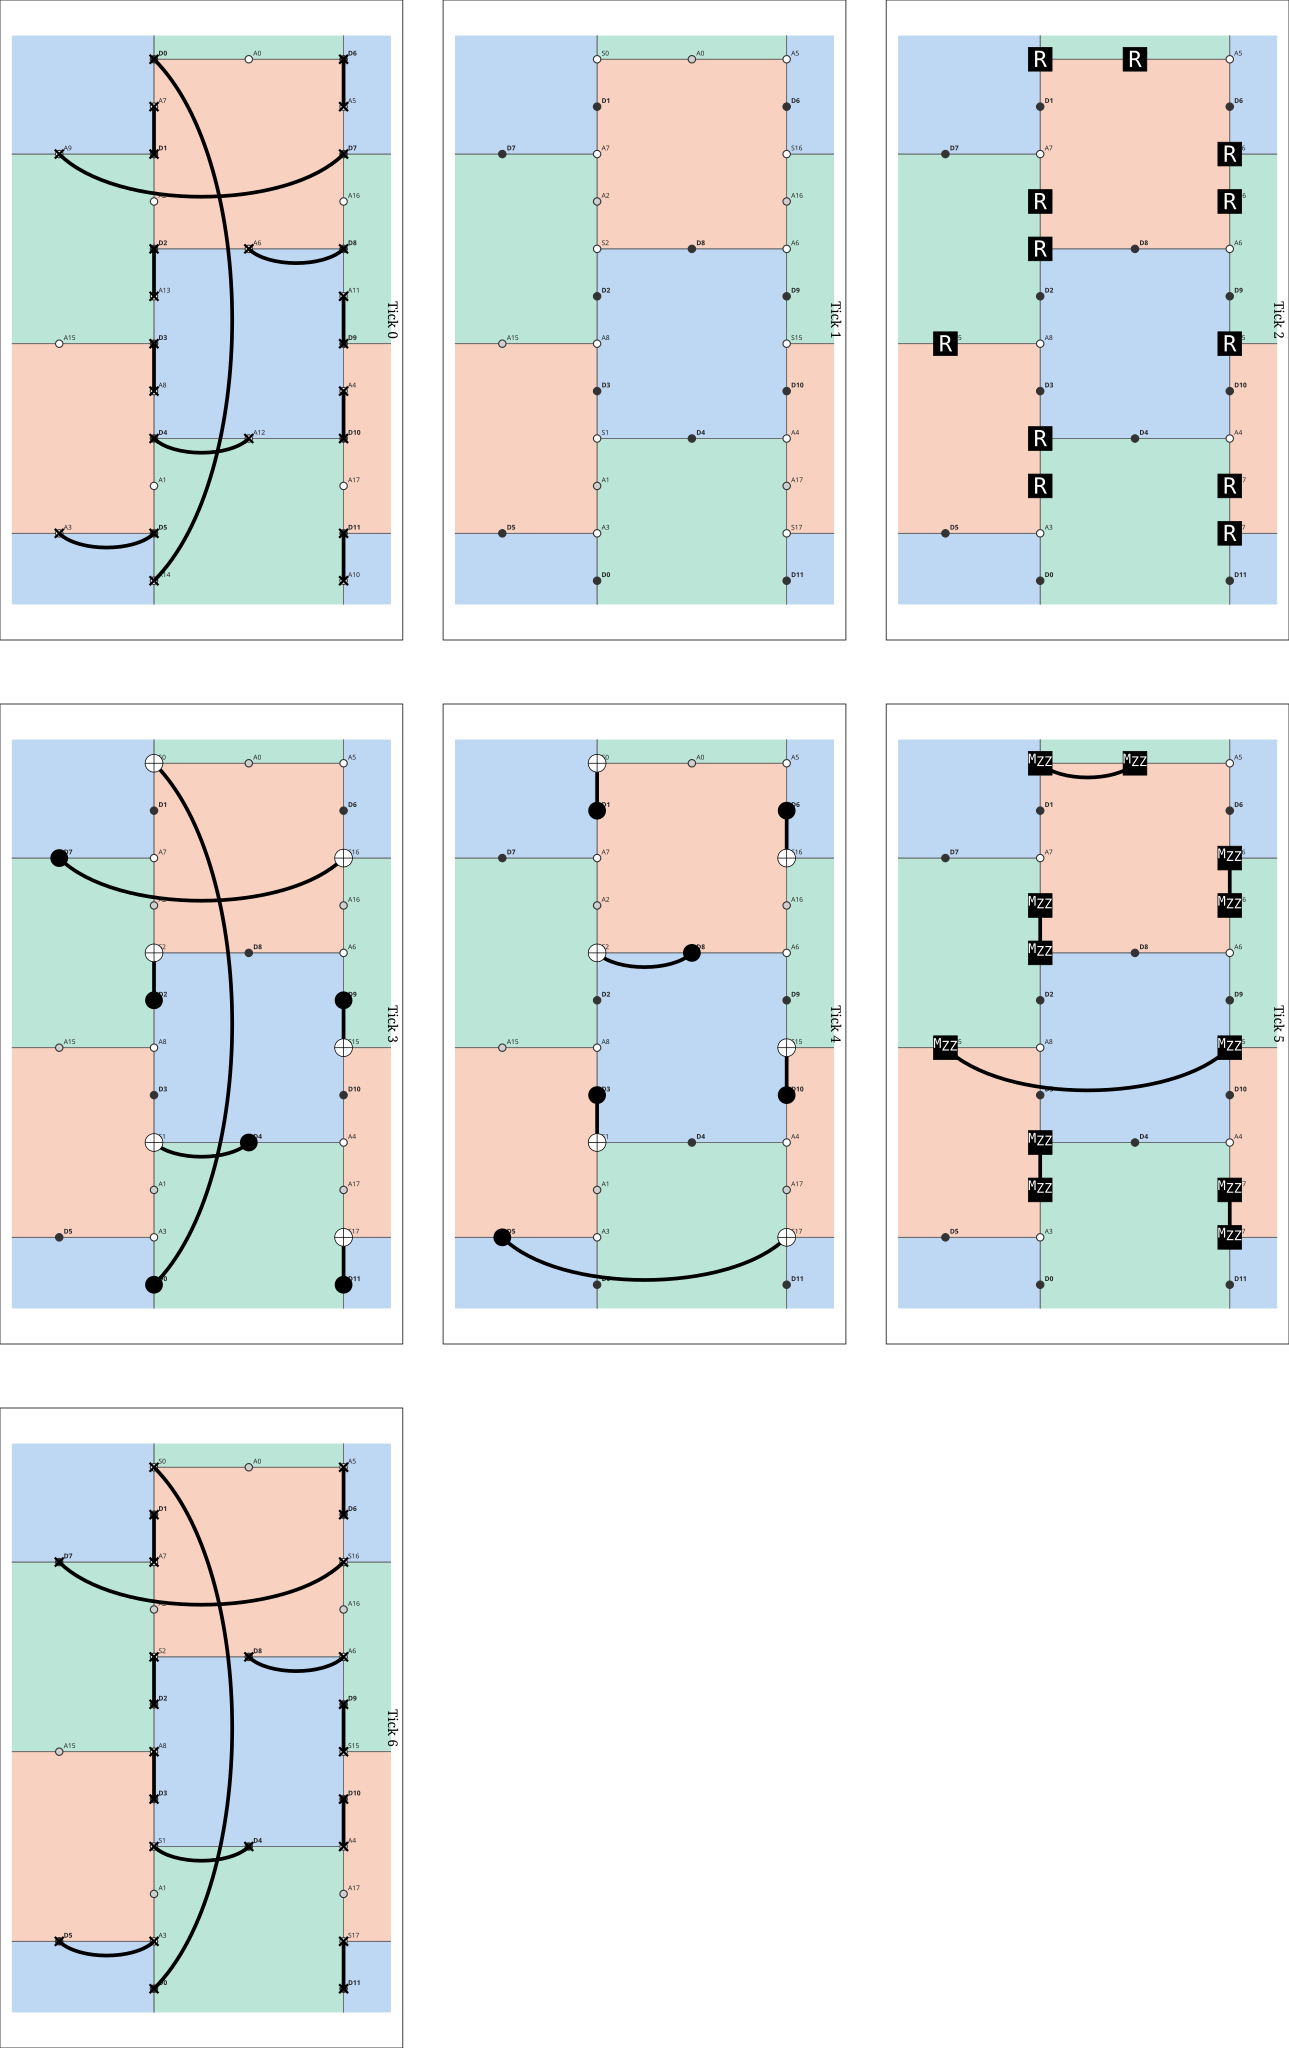

In [6]:
for r in range(6):
    print(f"step {r}: {'XZ'[r % 2] * 2} on {names[r % 3]} edges")
    display(SVG(round_svg(DISTANCE, r, hex_view=False, numbers=NUMBERS)))

## One step as a circuit

The gates behind step 0, with the QUBIT_COORDS lines dropped. The first and last SWAP layers are the
rotation and its undo; in between, every check runs its layer at the same time.

In [7]:
circuit = round_circuit(DISTANCE, 0)
print(f"{circuit.num_qubits} qubits, {circuit.num_ticks} ticks, {circuit.num_measurements} measurements\n")
print("\n".join(line for line in str(circuit).splitlines() if not line.startswith("QUBIT_COORDS")))

30 qubits, 8 ticks, 6 measurements

SWAP 7 17 8 28 2 18 1 14 0 19 6 12 4 20 5 13 11 15 10 29 9 16 3 27
TICK
TICK
RX 7
R 21
RX 11
R 22
RX 9
R 23
RX 4
R 24
RX 2
R 25
RX 0
R 26
TICK
CX 7 17 11 15 9 16 4 20 2 18 0 19
TICK
CX 7 28 11 29 9 27 4 13 2 14 0 12
TICK
H 7 11 9 4 2 0
TICK
MZZ 7 21 11 22 9 23 4 24 2 25 0 26
TICK
SWAP 7 17 8 28 2 18 1 14 0 19 6 12 4 20 5 13 11 15 10 29 9 16 3 27
TICK


## What is checked

`check` asserts, for every step: the rotation pairs each data qubit with one ancilla; the checks are one
whole colour class of real edges, each with its own reference; record j holds check j's parity (a stim
flow); the diagram labels match the circuit's MZZ pairs; and every data qubit is back where it started.
The script runs it before drawing anything.

In [8]:
check(DISTANCE)
print(f"d = {DISTANCE}: all steps check out")

d = 1: all steps check out
